# Model Evaluation


## Notebook Overview


This notebook evaluates the reconstruction-only U-Net and two Pix2Pix generators on the untouched test set. The reconstruction-only U-Net and the Pix2Pix generator from epoch 48 were both selected by the lowest validation $L_1$ within their respective runs, so the primary comparison applies one consistent selection rule. The Pix2Pix generator from epoch 20 is included as an additional reference because it was judged to produce the strongest qualitative results among the checkpoints examined in Notebook 04.

Two Pix2Pix checkpoints are therefore evaluated because the checkpoint selected by validation $L_1$ and the one preferred visually did not coincide, which is itself a result of the previous notebook. The epoch 50 checkpoint is excluded because it had the highest validation $L_1$ and the weakest visual quality among the three Pix2Pix checkpoints examined.

Performance is compared using MAE, PSNR, SSIM and LPIPS, both overall and separately for beds and dressers. The structural analysis tests whether input edge density is associated with reconstruction quality and whether generated images preserve the contours provided by their conditioning edge maps. Quantitative results are complemented by a fixed qualitative comparison of the three models.



## Setup and Environment

The evaluation is performed in Google Colab using the prepared paired dataset and the trained generator checkpoints stored in Google Drive. This section installs the additional package required for LPIPS, imports the required libraries, configures reproducibility and hardware, and defines the paths used throughout the notebook. No model training is performed.

In [1]:
%pip install -q torchmetrics lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.0 MB/s eta 0:00:00


In [30]:
import json
import random
import subprocess
import tarfile
import time
from pathlib import Path
import lpips

from tqdm.auto import tqdm

import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchmetrics
import torchvision
import torchvision.transforms.functional as TF
from google.colab import drive
from PIL import Image
from scipy.stats import spearmanr, wilcoxon
from torch.utils.data import DataLoader, Dataset

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

from torchmetrics.functional.image import (
    structural_similarity_index_measure,
)
from torchvision import transforms
from tqdm.auto import tqdm


plt.rcParams["figure.dpi"] = 72

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"TorchMetrics version: {torchmetrics.__version__}")

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
TorchMetrics version: 1.9.0


*Deterministic cuDNN settings are used because this notebook performs evaluation only, so reproducibility of the reported metrics is prioritized over the throughput optimizations applied during training.*

In [3]:
# Configure Reproducibility and Device
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device: {DEVICE}")

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [4]:
drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
DRIVE_ROOT = Path("/content/drive/MyDrive/Sketch2Furniture")

ARCHIVE_PATH = (
    DRIVE_ROOT / "colab_data" / "paired_dataset.tar"
)

UNET_CKPT_DIR = (
    DRIVE_ROOT / "checkpoints" / "unet_baseline"
)
PIX2PIX_CKPT_DIR = (
    DRIVE_ROOT / "checkpoints" / "pix2pix"
)

UNET_GENERATOR_PATH = (
    UNET_CKPT_DIR / "best_generator.pt"
)
PIX2PIX_BEST_GENERATOR_PATH = (
    PIX2PIX_CKPT_DIR / "best_generator.pt"
)
PIX2PIX_EPOCH_20_CHECKPOINT_PATH = (
    PIX2PIX_CKPT_DIR / "checkpoint_epoch_20.pt"
)

FIGURE_DIR = DRIVE_ROOT / "figures"
RESULTS_DIR = DRIVE_ROOT / "results"

LOCAL_ROOT = Path("/content")
PAIRED_DATA_DIR = (
    LOCAL_ROOT / "data" / "processed" / "paired"
)
PREPARED_METADATA_PATH = (
    PAIRED_DATA_DIR / "prepared_metadata.csv"
)
EXTRACTION_MARKER = (
    PAIRED_DATA_DIR / ".extraction_complete"
)

for required_path in (
    DRIVE_ROOT,
    ARCHIVE_PATH,
    UNET_GENERATOR_PATH,
    PIX2PIX_BEST_GENERATOR_PATH,
    PIX2PIX_EPOCH_20_CHECKPOINT_PATH,
):
    if not required_path.exists():
        raise FileNotFoundError(
            f"Required path not found: {required_path}"
        )

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

PER_IMAGE_METRICS_PATH = (RESULTS_DIR / "per_image_metrics.csv")

print(f"Drive project root: {DRIVE_ROOT}")
print(f"Baseline generator: {UNET_GENERATOR_PATH.name}")
print(f"Pix2Pix best generator: {PIX2PIX_BEST_GENERATOR_PATH.name}")
print(f"Pix2Pix epoch 20 checkpoint: {PIX2PIX_EPOCH_20_CHECKPOINT_PATH.name}")
print(f"Local paired-data directory: {PAIRED_DATA_DIR}")

Drive project root: /content/drive/MyDrive/Sketch2Furniture
Baseline generator: best_generator.pt
Pix2Pix best generator: best_generator.pt
Pix2Pix epoch 20 checkpoint: checkpoint_epoch_20.pt
Local paired-data directory: /content/data/processed/paired


In [6]:
# Extract Prepared Dataset
if (
    EXTRACTION_MARKER.is_file()
    and PREPARED_METADATA_PATH.is_file()
):
    print("Prepared dataset is already extracted.")
else:
    print("Extracting prepared dataset...")
    with tarfile.open(ARCHIVE_PATH, mode="r") as archive:
        archive.extractall(
            path=LOCAL_ROOT,
            filter="data",
        )
    if not PREPARED_METADATA_PATH.is_file():
        raise FileNotFoundError(
            "Prepared metadata was not found after extraction: "
            f"{PREPARED_METADATA_PATH}"
        )
    EXTRACTION_MARKER.touch()
    print("Prepared dataset extracted successfully.")

print(f"Prepared metadata: {PREPARED_METADATA_PATH}")
print(f"Extraction marker: {EXTRACTION_MARKER}")

Extracting prepared dataset...
Prepared dataset extracted successfully.
Prepared metadata: /content/data/processed/paired/prepared_metadata.csv
Extraction marker: /content/data/processed/paired/.extraction_complete


## Test Dataset and Data Loader


This section loads the prepared paired-image metadata and selects the untouched test split for evaluation. The conditioning edge maps are loaded as grayscale images, while the target furniture photographs are loaded as RGB images. Both are converted to tensors and normalized to the $[-1, 1]$ range used during training.

No data augmentation is applied during evaluation. The test loader preserves the metadata order, includes every test pair and returns the category and pair identifier required for per-image and per-category analysis.


In [7]:
# Load Prepared Metadata
prepared_metadata = pd.read_csv(PREPARED_METADATA_PATH)

required_columns = {
    "pair_id",
    "split",
    "category",
    "input_path",
    "target_path",
}

missing_columns = required_columns.difference(prepared_metadata.columns)

if missing_columns:
    raise ValueError(
        f"Prepared metadata is missing columns: {sorted(missing_columns)}"
    )


def rebuild_colab_path(stored_path):
    normalized_path = Path(str(stored_path).replace("\\", "/"))
    path_parts = normalized_path.parts

    try:
        paired_index = path_parts.index(PAIRED_DATA_DIR.name)
    except ValueError as error:
        raise ValueError(
            f"Could not locate '{PAIRED_DATA_DIR.name}' in path: {stored_path}"
        ) from error

    relative_path = Path(*path_parts[paired_index + 1 :])
    return PAIRED_DATA_DIR / relative_path


prepared_metadata["input_path"] = prepared_metadata["input_path"].map(
    rebuild_colab_path
)
prepared_metadata["target_path"] = prepared_metadata["target_path"].map(
    rebuild_colab_path
)

expected_splits = {"train", "validation", "test"}
observed_splits = set(prepared_metadata["split"].dropna().unique())

if observed_splits != expected_splits:
    raise ValueError(
        "Unexpected dataset splits. "
        f"Expected {sorted(expected_splits)}, "
        f"found {sorted(observed_splits)}."
    )

test_metadata = (
    prepared_metadata.loc[prepared_metadata["split"] == "test"]
    .reset_index(drop=True)
    .copy()
)

expected_test_pairs = 2892

if len(test_metadata) != expected_test_pairs:
    raise ValueError(
        f"Expected {expected_test_pairs} test pairs, "
        f"found {len(test_metadata)}."
    )

if test_metadata["pair_id"].duplicated().any():
    raise ValueError("Duplicate pair identifiers were found in the test split.")

missing_input_count = sum(
    not path.is_file() for path in test_metadata["input_path"]
)
missing_target_count = sum(
    not path.is_file() for path in test_metadata["target_path"]
)

if missing_input_count or missing_target_count:
    raise FileNotFoundError(
        f"Missing test inputs: {missing_input_count}; "
        f"missing test targets: {missing_target_count}."
    )

test_category_counts = (
    test_metadata["category"]
    .value_counts()
    .sort_index()
)

print(f"Prepared metadata pairs: {len(prepared_metadata)}")
print(f"Test pairs: {len(test_metadata)}")
print(f"Missing test inputs: {missing_input_count}")
print(f"Missing test targets: {missing_target_count}")
display(test_category_counts.rename("test_pairs").to_frame())

Prepared metadata pairs: 14318
Test pairs: 2892
Missing test inputs: 0
Missing test targets: 0


,test_pairs
category,
beds,1310
dressers,1582


In [8]:
# Define the paired dataset

class PairedFurnitureDataset(Dataset):
    def __init__(self, metadata, augment=False):
        self.metadata = metadata.reset_index(drop=True).copy()
        self.augment = augment

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, index):
        row = self.metadata.iloc[index]

        with Image.open(row["input_path"]) as image:
            input_image = image.convert("L")

        with Image.open(row["target_path"]) as image:
            target_image = image.convert("RGB")

        if self.augment and torch.rand(1).item() < 0.5:
            input_image = TF.hflip(input_image)
            target_image = TF.hflip(target_image)

        input_tensor = TF.to_tensor(input_image).mul(2).sub(1)
        target_tensor = TF.to_tensor(target_image).mul(2).sub(1)

        return {
            "input": input_tensor,
            "target": target_tensor,
            "pair_id": str(row["pair_id"]),
            "category": str(row["category"]),
        }

In [9]:
# Create the test loader

BATCH_SIZE = 8
NUM_WORKERS = 2
PIN_MEMORY = DEVICE.type == "cuda"

test_dataset = PairedFurnitureDataset(
    metadata=test_metadata,
    augment=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
    persistent_workers=NUM_WORKERS > 0,
)

print(f"Test dataset pairs: {len(test_dataset)}")
print(f"Test batches: {len(test_loader)}")
print(f"Batch size: {BATCH_SIZE}")
print("Shuffle: False")
print("Drop last: False")

Test dataset pairs: 2892
Test batches: 362
Batch size: 8
Shuffle: False
Drop last: False


In [10]:
# Verify One Batch

test_batch = next(iter(test_loader))

print(f"Input batch shape: {tuple(test_batch['input'].shape)}")
print(f"Target batch shape: {tuple(test_batch['target'].shape)}")
print(
    "Input range: "
    f"[{test_batch['input'].min().item():.3f}, "
    f"{test_batch['input'].max().item():.3f}]"
)
print(
    "Target range: "
    f"[{test_batch['target'].min().item():.3f}, "
    f"{test_batch['target'].max().item():.3f}]"
)
print(f"Categories: {test_batch['category'][:5]}")
print(f"Pair IDs: {test_batch['pair_id'][:5]}")

Input batch shape: (8, 1, 256, 256)
Target batch shape: (8, 3, 256, 256)
Input range: [-1.000, 1.000]
Target range: [-1.000, 1.000]
Categories: ['beds', 'beds', 'beds', 'beds', 'beds']
Pair IDs: ['pair_00008', 'pair_00012', 'pair_00013', 'pair_00025', 'pair_00030']


## Loading the Trained Generators

The three evaluated models use the same U-Net generator architecture defined during training. The reconstruction-only U-Net and the Pix2Pix generator selected at epoch 48 are stored as standalone generator state dictionaries, while the epoch 20 Pix2Pix model is retrieved from a complete training checkpoint.

Only the generator weights are required for evaluation. Each model is loaded on the selected device, placed in evaluation mode and frozen to prevent gradient computation.


In [11]:
# Define the U-Net Generator
class DownsampleBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        apply_batch_norm=True,
    ):
        super().__init__()
        layers = [
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=not apply_batch_norm,
            ),
        ]
        if apply_batch_norm:
            layers.append(
                nn.BatchNorm2d(out_channels)
            )
        layers.append(
            nn.LeakyReLU(
                negative_slope=0.2,
                inplace=True,
            )
        )
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class UpsampleBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        apply_dropout=False,
    ):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(
                in_channels,
                out_channels,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
        ]
        if apply_dropout:
            layers.append(nn.Dropout(0.5))
        layers.append(nn.ReLU(inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class UNetGenerator(nn.Module):
    def __init__(
        self,
        input_channels=1,
        output_channels=3,
    ):
        super().__init__()
        self.down1 = DownsampleBlock(
            input_channels,
            64,
            apply_batch_norm=False,
        )
        self.down2 = DownsampleBlock(64, 128)
        self.down3 = DownsampleBlock(128, 256)
        self.down4 = DownsampleBlock(256, 512)
        self.down5 = DownsampleBlock(512, 512)
        self.down6 = DownsampleBlock(512, 512)
        self.down7 = DownsampleBlock(512, 512)
        self.down8 = DownsampleBlock(
            512,
            512,
            apply_batch_norm=False,
        )
        self.up1 = UpsampleBlock(
            512,
            512,
            apply_dropout=True,
        )
        self.up2 = UpsampleBlock(
            1024,
            512,
            apply_dropout=True,
        )
        self.up3 = UpsampleBlock(
            1024,
            512,
            apply_dropout=True,
        )
        self.up4 = UpsampleBlock(1024, 512)
        self.up5 = UpsampleBlock(1024, 256)
        self.up6 = UpsampleBlock(512, 128)
        self.up7 = UpsampleBlock(256, 64)
        self.output_layer = nn.Sequential(
            nn.ConvTranspose2d(
                128,
                output_channels,
                kernel_size=4,
                stride=2,
                padding=1,
            ),
            nn.Tanh(),
        )

    def forward(self, x):
        down1 = self.down1(x)
        down2 = self.down2(down1)
        down3 = self.down3(down2)
        down4 = self.down4(down3)
        down5 = self.down5(down4)
        down6 = self.down6(down5)
        down7 = self.down7(down6)
        bottleneck = self.down8(down7)

        up1 = torch.cat(
            [self.up1(bottleneck), down7],
            dim=1,
        )
        up2 = torch.cat(
            [self.up2(up1), down6],
            dim=1,
        )
        up3 = torch.cat(
            [self.up3(up2), down5],
            dim=1,
        )
        up4 = torch.cat(
            [self.up4(up3), down4],
            dim=1,
        )
        up5 = torch.cat(
            [self.up5(up4), down3],
            dim=1,
        )
        up6 = torch.cat(
            [self.up6(up5), down2],
            dim=1,
        )
        up7 = torch.cat(
            [self.up7(up6), down1],
            dim=1,
        )
        return self.output_layer(up7)

In [12]:
# Loading Generator Weights
def load_generator(checkpoint_path):
    saved_object = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=True,
    )

    if (
        isinstance(saved_object, dict)
        and "generator_state_dict" in saved_object
    ):
        generator_state_dict = saved_object[
            "generator_state_dict"
        ]
    elif (
        isinstance(saved_object, dict)
        and all(
            torch.is_tensor(value)
            for value in saved_object.values()
        )
    ):
        generator_state_dict = saved_object
    else:
        raise ValueError(
            "Could not identify generator weights in: "
            f"{checkpoint_path}"
        )

    # Renaming Notebook 03's legacy output-layer keys
    renamed_state_dict = {}

    for key, value in generator_state_dict.items():
        if key.startswith("output."):
            key = (
                "output_layer."
                + key[len("output."):]
            )

        renamed_state_dict[key] = value

    loaded_generator = UNetGenerator()

    loaded_generator.load_state_dict(
        renamed_state_dict,
        strict=True,
    )

    loaded_generator.requires_grad_(False)
    loaded_generator.eval()
    loaded_generator.to(DEVICE)

    return loaded_generator

In [13]:
# Loading Evaluated Generators

generator_checkpoints = {
    "Reconstruction-only U-Net": UNET_GENERATOR_PATH,
    "Pix2Pix epoch 20": PIX2PIX_EPOCH_20_CHECKPOINT_PATH,
    "Pix2Pix epoch 48": PIX2PIX_BEST_GENERATOR_PATH,
}

generators = {}

for model_name, checkpoint_path in generator_checkpoints.items():
    generators[model_name] = load_generator(
        checkpoint_path
    )

    print(
        f"Loaded {model_name}: "
        f"{checkpoint_path.name}"
    )

Loaded Reconstruction-only U-Net: best_generator.pt
Loaded Pix2Pix epoch 20: checkpoint_epoch_20.pt
Loaded Pix2Pix epoch 48: best_generator.pt


In [14]:
# Verifing Loaded Generators
for model_name, loaded_generator in generators.items():
    parameter_count = sum(
        parameter.numel()
        for parameter in loaded_generator.parameters()
    )
    model_device = next(
        loaded_generator.parameters()
    ).device
    parameters_frozen = all(
        not parameter.requires_grad
        for parameter in loaded_generator.parameters()
    )

    print(
        f"{model_name}: "
        f"parameters={parameter_count}, "
        f"device={model_device}, "
        f"evaluation={not loaded_generator.training}, "
        f"frozen={parameters_frozen}"
    )

Reconstruction-only U-Net: parameters=54412483, device=cuda:0, evaluation=True, frozen=True
Pix2Pix epoch 20: parameters=54412483, device=cuda:0, evaluation=True, frozen=True
Pix2Pix epoch 48: parameters=54412483, device=cuda:0, evaluation=True, frozen=True


### Observation

All three generators were loaded successfully using the shared U-Net architecture. The models have identical parameter counts and are placed on the GPU in evaluation mode with gradients disabled, confirming that they are ready for consistent test-set inference.


## Evaluation Metrics


Four full-reference metrics and one conditioning-consistency metric are calculated independently for every generated test image. Mean absolute error (MAE) is calculated directly from the normalized prediction and target tensors in the $[-1, 1]$ range. This preserves direct comparability with the previously reported MAE values of 0.2131 and 0.2395. Although the image tensors are normalized to $[-1, 1]$, the resulting MAE has a theoretical range from 0 to 2.

Peak signal-to-noise ratio (PSNR) and structural similarity index measure (SSIM) are calculated after denormalizing the generated and target images to $[0, 1]$, with the data range fixed at 1.0. Learned perceptual image patch similarity (LPIPS) uses the original RGB tensors in $[-1, 1]$, as expected by the reference implementation. Lower values indicate better performance for MAE and LPIPS, while higher values indicate better performance for PSNR and SSIM.

Round-trip edge IoU measures preservation of the conditioning sketch. The generated RGB image is processed using the same grayscale conversion, Gaussian blur and Canny thresholds applied during dataset preparation. Its resulting edges are compared with the original input edges using a symmetric one-pixel tolerance based on a $3 \times 3$ neighborhood. Higher edge IoU indicates better structural consistency with the conditioning sketch.

The individual score for every test pair is retained instead of storing only batch or dataset averages. These per-image results support overall and per-category summaries, paired Wilcoxon tests and Spearman correlation analysis. The expected perceptual advantage of Pix2Pix is treated as a hypothesis rather than an assumed outcome. The observed LPIPS results will therefore be reported unchanged and interpreted together with the qualitative evidence, including visible blur and generation artifacts.

In [15]:
# Initialize the LPIPS Metric
LPIPS_MODEL = lpips.LPIPS(
    net="alex",
    version="0.1",
    verbose=False,
).to(DEVICE)

LPIPS_MODEL.requires_grad_(False)
LPIPS_MODEL.eval()

print("LPIPS network: AlexNet")
print("LPIPS version: 0.1")
print(f"LPIPS device: {next(LPIPS_MODEL.parameters()).device}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 163MB/s]


LPIPS network: AlexNet
LPIPS version: 0.1
LPIPS device: cuda:0


In [16]:
# Calculate Per-Image Evaluation Metrics
@torch.inference_mode()
def calculate_per_image_metrics(
    predictions,
    targets,
    lpips_model,
):
    if predictions.shape != targets.shape:
        raise ValueError(
            "Predictions and targets must have identical shapes. "
            f"Found {tuple(predictions.shape)} and "
            f"{tuple(targets.shape)}."
        )

    if predictions.ndim != 4:
        raise ValueError(
            "Expected image tensors with shape "
            "(batch, channels, height, width)."
        )

    # Use float32 for stable metric calculations
    predictions = predictions.float()
    targets = targets.float()

    # MAE on tensors normalized to [-1, 1]
    mae_values = torch.abs(
        predictions - targets
    ).mean(dim=(1, 2, 3))

    # Denormalize to [0, 1] for PSNR and SSIM
    predictions_01 = (
        predictions.add(1).div(2).clamp(0, 1)
    )
    targets_01 = (
        targets.add(1).div(2).clamp(0, 1)
    )

    mse_values = (
        predictions_01 - targets_01
    ).square().mean(dim=(1, 2, 3))

    # Prevent infinite PSNR for zero-MSE reconstructions
    psnr_values = -10.0 * torch.log10(
    mse_values.clamp_min(1e-12)
    )

    ssim_values = (
        structural_similarity_index_measure(
            predictions_01,
            targets_01,
            data_range=1.0,
            reduction="none",
        )
    )

    # LPIPS natively expects RGB tensors in [-1, 1]
    lpips_values = lpips_model(
        predictions,
        targets,
    ).flatten()

    metric_values = {
        "mae": mae_values,
        "psnr": psnr_values,
        "ssim": ssim_values,
        "lpips": lpips_values,
    }

    expected_shape = (predictions.shape[0],)

    for metric_name, values in metric_values.items():
        if values.shape != expected_shape:
            raise ValueError(
                f"Unexpected {metric_name.upper()} shape: "
                f"{tuple(values.shape)}; "
                f"expected {expected_shape}."
            )

    return metric_values

In [17]:
# Verify Per-Image Metric Calculation
metric_test_batch = next(iter(test_loader))

metric_test_inputs = metric_test_batch[
    "input"
][:2].to(
    DEVICE,
    non_blocking=PIN_MEMORY,
)
metric_test_targets = metric_test_batch[
    "target"
][:2].to(
    DEVICE,
    non_blocking=PIN_MEMORY,
)

print(f"Test pair IDs: {metric_test_batch['pair_id'][:2]}")

with torch.inference_mode():
    for model_name, generator in generators.items():
        metric_test_predictions = generator(
            metric_test_inputs
        )

        metric_test_values = (
            calculate_per_image_metrics(
                metric_test_predictions,
                metric_test_targets,
                LPIPS_MODEL,
            )
        )

        print(f"\n{model_name}")

        for metric_name, values in metric_test_values.items():
            formatted_values = ", ".join(
                f"{value:.4f}"
                for value in values.cpu().tolist()
            )
            all_finite = torch.isfinite(
                values
            ).all().item()

            print(
                f"{metric_name.upper()}: "
                f"shape={tuple(values.shape)}, "
                f"finite={all_finite}, "
                f"values=[{formatted_values}]"
            )

Test pair IDs: ['pair_00008', 'pair_00012']

Reconstruction-only U-Net
MAE: shape=(2,), finite=True, values=[0.2596, 0.2357]
PSNR: shape=(2,), finite=True, values=[13.9538, 15.2292]
SSIM: shape=(2,), finite=True, values=[0.8096, 0.6789]
LPIPS: shape=(2,), finite=True, values=[0.2980, 0.2713]

Pix2Pix epoch 20
MAE: shape=(2,), finite=True, values=[0.2181, 0.4222]
PSNR: shape=(2,), finite=True, values=[15.1289, 10.5924]
SSIM: shape=(2,), finite=True, values=[0.7342, 0.5226]
LPIPS: shape=(2,), finite=True, values=[0.3410, 0.3823]

Pix2Pix epoch 48
MAE: shape=(2,), finite=True, values=[0.2276, 0.2953]
PSNR: shape=(2,), finite=True, values=[14.9675, 13.0966]
SSIM: shape=(2,), finite=True, values=[0.7692, 0.5738]
LPIPS: shape=(2,), finite=True, values=[0.2869, 0.3250]


In [18]:
# Configure Round-Trip Edge Extraction
CANNY_LOW_THRESHOLD = 100
CANNY_HIGH_THRESHOLD = 200
GAUSSIAN_KERNEL_SIZE = (5, 5)

EDGE_TOLERANCE_KERNEL = np.ones(
    (3, 3),
    dtype=np.uint8,
)


# Calculate Per-Image Round-Trip Edge IoU
@torch.inference_mode()
def calculate_round_trip_edge_iou(
    predictions,
    input_sketches,
):
    if predictions.ndim != 4:
        raise ValueError(
            "Expected predictions with shape "
            "(batch, channels, height, width)."
        )

    if input_sketches.ndim != 4:
        raise ValueError(
            "Expected input sketches with shape "
            "(batch, channels, height, width)."
        )

    if predictions.shape[1] != 3:
        raise ValueError(
            "Expected three-channel RGB predictions."
        )

    if input_sketches.shape[1] != 1:
        raise ValueError(
            "Expected one-channel input sketches."
        )

    if (
        predictions.shape[0]
        != input_sketches.shape[0]
        or predictions.shape[2:]
        != input_sketches.shape[2:]
    ):
        raise ValueError(
            "Predictions and input sketches must have "
            "matching batch and spatial dimensions."
        )

    # Convert generated images from [-1, 1] to uint8 RGB
    prediction_images = (
        predictions.float()
        .add(1)
        .div(2)
        .clamp(0, 1)
        .mul(255)
        .round()
        .to(torch.uint8)
        .permute(0, 2, 3, 1)
        .contiguous()
        .cpu()
        .numpy()
    )

    # Prepared sketches contain black edges on white backgrounds
    reference_edge_masks = (
        input_sketches[:, 0]
        .lt(0)
        .to(torch.uint8)
        .contiguous()
        .cpu()
        .numpy()
    )

    edge_iou_values = []

    for prediction_image, reference_edge_mask in zip(
        prediction_images,
        reference_edge_masks,
    ):
        generated_gray = cv2.cvtColor(
            prediction_image,
            cv2.COLOR_RGB2GRAY,
        )

        generated_blurred = cv2.GaussianBlur(
            generated_gray,
            GAUSSIAN_KERNEL_SIZE,
            sigmaX=0,
        )

        generated_edge_mask = cv2.Canny(
            generated_blurred,
            threshold1=CANNY_LOW_THRESHOLD,
            threshold2=CANNY_HIGH_THRESHOLD,
        ).astype(bool)

        reference_edge_mask = (
            reference_edge_mask.astype(bool)
        )

        reference_neighborhood = cv2.dilate(
            reference_edge_mask.astype(np.uint8),
            EDGE_TOLERANCE_KERNEL,
            iterations=1,
        ).astype(bool)

        generated_neighborhood = cv2.dilate(
            generated_edge_mask.astype(np.uint8),
            EDGE_TOLERANCE_KERNEL,
            iterations=1,
        ).astype(bool)

        generated_match_count = int(
            np.logical_and(
                generated_edge_mask,
                reference_neighborhood,
            ).sum()
        )

        reference_match_count = int(
            np.logical_and(
                reference_edge_mask,
                generated_neighborhood,
            ).sum()
        )

        intersection_count = min(
            generated_match_count,
            reference_match_count,
        )

        generated_edge_count = int(
            generated_edge_mask.sum()
        )
        reference_edge_count = int(
            reference_edge_mask.sum()
        )

        union_count = (
            generated_edge_count
            + reference_edge_count
            - intersection_count
        )

        if union_count == 0:
            edge_iou = 1.0
        else:
            edge_iou = (
                intersection_count / union_count
            )

        edge_iou_values.append(edge_iou)

    return torch.tensor(
        edge_iou_values,
        dtype=torch.float32,
    )

In [19]:
# Verify Round-Trip Edge IoU
with torch.inference_mode():
    for model_name, generator in generators.items():
        metric_test_predictions = generator(
            metric_test_inputs
        )

        edge_iou_test_values = (
            calculate_round_trip_edge_iou(
                metric_test_predictions,
                metric_test_inputs,
            )
        )

        values_finite = torch.isfinite(
            edge_iou_test_values
        ).all().item()

        values_in_range = (
            (edge_iou_test_values >= 0)
            & (edge_iou_test_values <= 1)
        ).all().item()

        formatted_values = ", ".join(
            f"{value:.4f}"
            for value in edge_iou_test_values.tolist()
        )

        print(
            f"{model_name}: "
            f"shape={tuple(edge_iou_test_values.shape)}, "
            f"finite={values_finite}, "
            f"in_range={values_in_range}, "
            f"values=[{formatted_values}]"
        )

Reconstruction-only U-Net: shape=(2,), finite=True, in_range=True, values=[0.9279, 0.7971]
Pix2Pix epoch 20: shape=(2,), finite=True, in_range=True, values=[0.9477, 0.9295]
Pix2Pix epoch 48: shape=(2,), finite=True, in_range=True, values=[0.9520, 0.9256]


## Generating Test Predictions

The complete test set is processed once by each generator under inference mode. Each generated batch is evaluated immediately using MAE, PSNR, SSIM, LPIPS and round-trip edge IoU, avoiding an additional generator pass for the conditioning-consistency analysis.

All scores are retained per image together with the corresponding pair identifier and model name. Input edge density is also recorded as the proportion of black sketch pixels in the range $[0, 1]$. This represents the same underlying quantity reported as a percentage in Notebook 02, but uses a proportional scale here to support the later Spearman correlation analysis.


In [20]:
# Evaluate Generators on the Complete Test Set

if PER_IMAGE_METRICS_PATH.exists():
    evaluation_results = pd.read_csv(
        PER_IMAGE_METRICS_PATH
    )

    print(
        "Loaded existing per-image metrics: "
        f"{len(evaluation_results)} rows"
    )

else:
    evaluation_records = []

    with torch.inference_mode():
        for model_name, generator in generators.items():
            print(f"Evaluating {model_name}...")

            for batch in tqdm(
                test_loader,
                desc=model_name,
                leave=True,
            ):
                inputs = batch["input"].to(
                    DEVICE,
                    non_blocking=PIN_MEMORY,
                )
                targets = batch["target"].to(
                    DEVICE,
                    non_blocking=PIN_MEMORY,
                )
                pair_ids = list(batch["pair_id"])

                predictions = generator(inputs)

                batch_metrics = (
                    calculate_per_image_metrics(
                        predictions,
                        targets,
                        LPIPS_MODEL,
                    )
                )

                batch_metrics["edge_iou"] = (
                    calculate_round_trip_edge_iou(
                        predictions,
                        inputs,
                    )
                )

                # Match Notebook 02's black-pixel definition
                edge_density_values = (
                    inputs.lt(0)
                    .float()
                    .mean(dim=(1, 2, 3))
                    .cpu()
                    .tolist()
                )

                batch_metric_values = {
                    metric_name: values.cpu().tolist()
                    for metric_name, values
                    in batch_metrics.items()
                }

                for image_index, pair_id in enumerate(
                    pair_ids
                ):
                    evaluation_records.append(
                        {
                            "pair_id": pair_id,
                            "model": model_name,
                            "mae": batch_metric_values[
                                "mae"
                            ][image_index],
                            "psnr": batch_metric_values[
                                "psnr"
                            ][image_index],
                            "ssim": batch_metric_values[
                                "ssim"
                            ][image_index],
                            "lpips": batch_metric_values[
                                "lpips"
                            ][image_index],
                            "edge_iou": (
                                batch_metric_values[
                                    "edge_iou"
                                ][image_index]
                            ),
                            "edge_density": (
                                edge_density_values[
                                    image_index
                                ]
                            ),
                        }
                    )

                del (
                    inputs,
                    targets,
                    predictions,
                    batch_metrics,
                    batch_metric_values,
                    edge_density_values,
                )

            print(f"Completed {model_name}.")

    evaluation_results = pd.DataFrame(
        evaluation_records
    )

    print(
        f"Evaluation rows created: "
        f"{len(evaluation_results)}"
    )

Loaded existing per-image metrics: 8676 rows


The per-image results are merged with the test metadata to attach category labels, then checked for completeness and numerical stability. The verified table is saved to Google Drive so that the later analysis can reuse it without regenerating predictions.

In [21]:
# Validate and Save Per-Image Evaluation Results

test_pair_metadata = (
    test_metadata[
        ["pair_id", "category"]
    ]
    .drop_duplicates(subset="pair_id")
    .copy()
)

evaluation_results = evaluation_results.drop(
    columns="category",
    errors="ignore",
)

evaluation_results = evaluation_results.merge(
    test_pair_metadata,
    on="pair_id",
    how="left",
    validate="many_to_one",
)

metric_columns = [
    "mae",
    "psnr",
    "ssim",
    "lpips",
    "edge_iou",
    "edge_density",
]

expected_model_names = list(generators.keys())
expected_pair_count = (
    test_pair_metadata["pair_id"].nunique()
)
expected_rows = (
    expected_pair_count
    * len(expected_model_names)
)

if len(evaluation_results) != expected_rows:
    raise ValueError(
        "Unexpected evaluation-result count: "
        f"{len(evaluation_results)}; "
        f"expected {expected_rows}."
    )

if evaluation_results.duplicated(
    subset=["pair_id", "model"]
).any():
    raise ValueError(
        "Duplicate pair-model evaluation rows "
        "were detected."
    )

if evaluation_results["category"].isna().any():
    raise ValueError(
        "Some evaluation rows have no category."
    )

if not np.isfinite(
    evaluation_results[
        metric_columns
    ].to_numpy()
).all():
    raise ValueError(
        "Non-finite metric values were detected."
    )

if not evaluation_results[
    "edge_iou"
].between(0, 1).all():
    raise ValueError(
        "Edge IoU values outside [0, 1] "
        "were detected."
    )

if not evaluation_results[
    "edge_density"
].between(0, 1).all():
    raise ValueError(
        "Edge-density values outside [0, 1] "
        "were detected."
    )

model_counts = (
    evaluation_results["model"]
    .value_counts()
    .reindex(expected_model_names)
)

if (
    model_counts.isna().any()
    or not model_counts.eq(
        expected_pair_count
    ).all()
):
    raise ValueError(
        "One or more models do not have exactly "
        f"{expected_pair_count} evaluation rows."
    )

edge_density_counts = (
    evaluation_results
    .groupby("pair_id")["edge_density"]
    .nunique(dropna=False)
)

if not edge_density_counts.eq(1).all():
    raise ValueError(
        "Edge density is inconsistent across "
        "models for one or more test pairs."
    )


evaluation_results.to_csv(
    PER_IMAGE_METRICS_PATH,
    index=False,
)

print("Rows per model:")
print(model_counts.astype(int).to_string())

print(
    f"\nUnique test pairs: "
    f"{evaluation_results['pair_id'].nunique()}"
)

print(
    "Edge density consistent across models: "
    f"{edge_density_counts.eq(1).all()}"
)

print(
    f"Saved per-image metrics to: "
    f"{PER_IMAGE_METRICS_PATH}"
)

Rows per model:
model
Reconstruction-only U-Net    2892
Pix2Pix epoch 20             2892
Pix2Pix epoch 48             2892

Unique test pairs: 2892
Edge density consistent across models: True
Saved per-image metrics to: /content/drive/MyDrive/Sketch2Furniture/results/per_image_metrics.csv


## Overall Results

Overall performance is first summarized descriptively across all 2892 test pairs. The models are then compared using paired statistical tests because every generator was evaluated on the same images.

The primary comparison is between the reconstruction-only U-Net and Pix2Pix epoch 48, as both checkpoints were selected using the same validation-based rule. Comparisons involving Pix2Pix epoch 20 are treated as secondary. Wilcoxon signed-rank tests are performed for the five model-performance metrics, with Holm correction applied across the complete family of 15 tests. Median paired differences are reported alongside the p-values so that statistical significance is not mistaken for a practically meaningful improvement at this large sample size. Input edge density is excluded because it describes the conditioning sketch and is identical across models.



### Descriptive Metric Summary

The mean, standard deviation and median are calculated for MAE, PSNR, SSIM, LPIPS and round-trip edge IoU. Lower values indicate better performance for MAE and LPIPS, while higher values indicate better performance for PSNR, SSIM and edge IoU.

In [22]:
# Summarize Overall Evaluation Metrics


performance_metric_columns = [
    "mae",
    "psnr",
    "ssim",
    "lpips",
    "edge_iou",
]

metric_display_names = {
    "mae": "MAE",
    "psnr": "PSNR",
    "ssim": "SSIM",
    "lpips": "LPIPS",
    "edge_iou": "Edge IoU",
}

metric_directions = {
    "mae": "lower is better",
    "psnr": "higher is better",
    "ssim": "higher is better",
    "lpips": "lower is better",
    "edge_iou": "higher is better",
}

summary_index = pd.MultiIndex.from_product(
    [
        expected_model_names,
        performance_metric_columns,
    ],
    names=["model", "metric"],
)

overall_metric_summary = (
    evaluation_results
    .melt(
        id_vars=["pair_id", "model"],
        value_vars=performance_metric_columns,
        var_name="metric",
        value_name="value",
    )
    .groupby(
        ["model", "metric"],
        sort=False,
    )["value"]
    .agg(
        count="count",
        mean="mean",
        std="std",
        median="median",
    )
    .reindex(summary_index)
    .reset_index()
)

if overall_metric_summary[
    ["count", "mean", "std", "median"]
].isna().any().any():
    raise ValueError(
        "The overall metric summary contains "
        "missing values."
    )

if not overall_metric_summary[
    "count"
].eq(expected_pair_count).all():
    raise ValueError(
        "One or more summary rows have an "
        "unexpected image count."
    )

OVERALL_METRICS_PATH = (
    RESULTS_DIR / "overall_metric_summary.csv"
)

overall_metric_summary.to_csv(
    OVERALL_METRICS_PATH,
    index=False,
)

overall_metric_summary_display = (
    overall_metric_summary.copy()
)

overall_metric_summary_display["metric"] = (
    overall_metric_summary_display["metric"]
    .map(metric_display_names)
)

overall_metric_summary_display[
    ["mean", "std", "median"]
] = overall_metric_summary_display[
    ["mean", "std", "median"]
].round(4)

display(overall_metric_summary_display)

print(
    f"Saved overall metric summary to: "
    f"{OVERALL_METRICS_PATH}"
)

,model,metric,count,mean,std,median
0,Reconstruction-only U-Net,MAE,2892,0.2164,0.1324,0.1787
1,Reconstruction-only U-Net,PSNR,2892,16.9939,4.0202,17.0699
2,Reconstruction-only U-Net,SSIM,2892,0.6624,0.1237,0.6733
3,Reconstruction-only U-Net,LPIPS,2892,0.3426,0.1070,0.3312
4,Reconstruction-only U-Net,Edge IoU,2892,0.6926,0.1910,0.7089
5,Pix2Pix epoch 20,MAE,2892,0.2527,0.1353,0.2214
6,Pix2Pix epoch 20,PSNR,2892,15.3258,3.6736,15.2140
7,Pix2Pix epoch 20,SSIM,2892,0.5534,0.1219,0.5603
8,Pix2Pix epoch 20,LPIPS,2892,0.3472,0.0837,0.3399
9,Pix2Pix epoch 20,Edge IoU,2892,0.8511,0.0884,0.8572


Saved overall metric summary to: /content/drive/MyDrive/Sketch2Furniture/results/overall_metric_summary.csv


The per-image metric distributions are visualized to complement the aggregate summary statistics. Each box represents the interquartile range, the central line marks the median, the diamond marks the mean and the individual points show observations beyond the whiskers. Separate axes are used because the five metrics have different scales and directions of improvement.


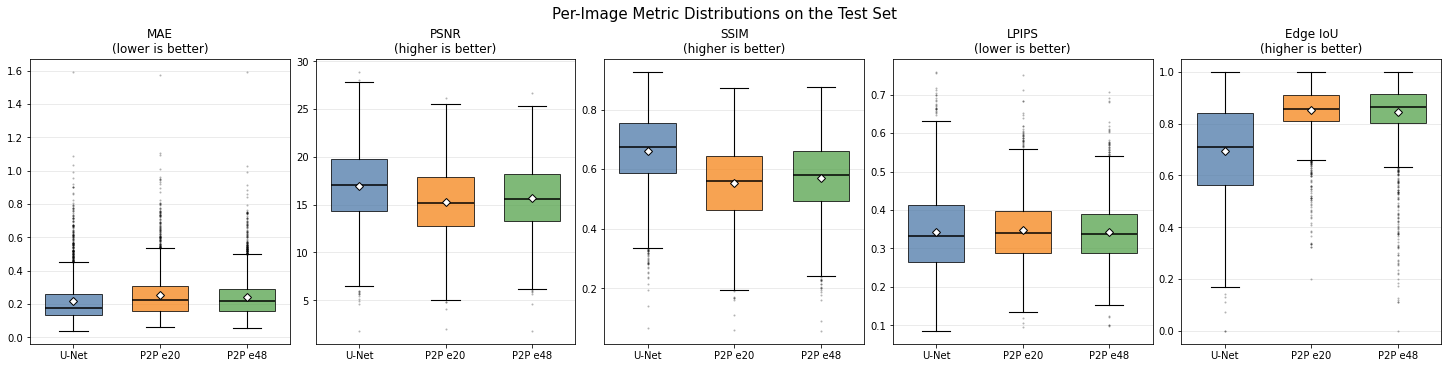

Saved metric-distribution figure to: /content/drive/MyDrive/Sketch2Furniture/figures/test_metric_distributions.png


In [23]:
# Compare Metric Distributions Across Models
short_model_names = {
    "Reconstruction-only U-Net": "U-Net",
    "Pix2Pix epoch 20": "P2P e20",
    "Pix2Pix epoch 48": "P2P e48",
}

model_colors = {
    "Reconstruction-only U-Net": "#4C78A8",
    "Pix2Pix epoch 20": "#F58518",
    "Pix2Pix epoch 48": "#54A24B",
}

figure, axes = plt.subplots(
    1,
    len(performance_metric_columns),
    figsize=(
        4 * len(performance_metric_columns),
        5,
    ),
    constrained_layout=True,
)

for axis, metric_name in zip(
    axes,
    performance_metric_columns,
):
    metric_distributions = [
        evaluation_results.loc[
            evaluation_results["model"]
            == model_name,
            metric_name,
        ].to_numpy()
        for model_name in expected_model_names
    ]

    boxplot_artists = axis.boxplot(
        metric_distributions,
        tick_labels=[
            short_model_names[model_name]
            for model_name in expected_model_names
        ],
        patch_artist=True,
        showmeans=True,
        widths=0.65,
        medianprops={
            "color": "black",
            "linewidth": 1.5,
        },
        meanprops={
            "marker": "D",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markersize": 5,
        },
        whiskerprops={
            "linewidth": 1.1,
        },
        capprops={
            "linewidth": 1.1,
        },
        flierprops={
            "marker": ".",
            "markersize": 2,
            "alpha": 0.3,
        },
    )

    for box, model_name in zip(
        boxplot_artists["boxes"],
        expected_model_names,
    ):
        box.set_facecolor(
            model_colors[model_name]
        )
        box.set_alpha(0.75)

    axis.set_title(
        f"{metric_display_names[metric_name]}\n"
        f"({metric_directions[metric_name]})"
    )
    axis.grid(
        alpha=0.3,
        axis="y",
    )
    axis.set_axisbelow(True)

figure.suptitle(
    "Per-Image Metric Distributions on the Test Set",
    fontsize=15,
)

METRIC_DISTRIBUTIONS_PATH = (
    FIGURE_DIR
    / "test_metric_distributions.png"
)

figure.savefig(
    METRIC_DISTRIBUTIONS_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved metric-distribution figure to: "
    f"{METRIC_DISTRIBUTIONS_PATH}"
)

### Observation

The reconstruction-only U-Net achieves the best MAE, PSNR and SSIM, with a mean MAE of 0.2164 against 0.2408 for Pix2Pix epoch 48 and a mean SSIM of 0.6624 against 0.5713. This ordering is consistent with the validation results reported during model selection in Notebooks 03 and 04.

LPIPS does not provide a clear descriptive separation between the reconstruction-only U-Net and Pix2Pix epoch 48. Epoch 48 records the lowest mean LPIPS at 0.3421 against 0.3426 for the baseline, a difference of only 0.0005, while the baseline records the lower median at 0.3312 against 0.3371. The baseline also shows greater variability, with a standard deviation of 0.1070 against 0.0784. Together with its mean being above its median, this suggests a longer upper tail containing perceptually poorer reconstructions.

Round-trip edge IoU separates the models clearly and in the opposite direction, reaching approximately 0.85 for both Pix2Pix checkpoints against 0.6926 for the baseline. This metric measures the tolerant overlap between the conditioning-sketch edges and the edges re-extracted from the generated image using the same Canny configuration. The result therefore indicates that the adversarially trained generators preserve the given contours more faithfully.

The distributions also differ in shape. The Pix2Pix values are concentrated in a narrow band near 0.86, although a minority of low outliers extend towards zero, while the baseline values are spread broadly across their interquartile range. The adversarially trained generators are therefore more consistently faithful to the conditioning contours, despite occasional failures, whereas the baseline is generally less faithful and more variable.

Between the two Pix2Pix checkpoints, epoch 48 leads on MAE, PSNR, SSIM and LPIPS, while their edge-IoU results are close. This ordering differs from the qualitative assessment in Notebook 04, where epoch 20 was preferred visually. For all three models, the mean MAE is above the median, which is consistent with right-skewed error distributions and suggests that a subset of test pairs produces considerably higher reconstruction errors, with outliers reaching approximately 1.6 on the theoretical $[0, 2]$ MAE range implied by the $[-1, 1]$ image normalization. Whether the observed paired differences are statistically reliable is examined in the following subsection.


### Paired Statistical Comparison

Two-sided Wilcoxon signed-rank tests are used to examine whether the paired per-image differences are centred around zero. The primary comparison evaluates the reconstruction-only U-Net against Pix2Pix epoch 48, since both checkpoints were selected using the same validation-based rule. Comparisons involving Pix2Pix epoch 20 are treated as secondary.

For each comparison, the paired difference is defined as the value for model B minus the value for model A. Negative differences favour model B for MAE and LPIPS, while positive differences favour model B for PSNR, SSIM and edge IoU. Holm-adjusted p-values control the family-wise error rate across all 15 tests. Median paired differences are reported alongside the p-values to distinguish statistical reliability from practical importance.

In [24]:
# Compare Models Using Paired Wilcoxon Tests

def format_p_value(value):
    return (
        "< 1e-300"
        if value == 0
        else f"{value:.3e}"
    )

model_comparisons = (
    ("Primary", "Reconstruction-only U-Net", "Pix2Pix epoch 48"),
    ("Secondary", "Reconstruction-only U-Net", "Pix2Pix epoch 20"),
    ("Secondary", "Pix2Pix epoch 20", "Pix2Pix epoch 48"),
)

paired_metric_tables = {}
for metric_name in performance_metric_columns:
    paired_table = (
        evaluation_results
        .pivot(
            index="pair_id",
            columns="model",
            values=metric_name,
        )
        .reindex(columns=expected_model_names)
        .sort_index()
    )
    if (
        len(paired_table) != expected_pair_count
        or paired_table.isna().any().any()
    ):
        raise ValueError(
            f"Incomplete paired values for {metric_name}."
        )
    paired_metric_tables[metric_name] = paired_table

wilcoxon_records = []

for comparison_role, model_a, model_b in model_comparisons:
    for metric_name in performance_metric_columns:
        paired_table = paired_metric_tables[metric_name]
        differences = (
            paired_table[model_b]
            - paired_table[model_a]
        ).to_numpy()
        test_result = wilcoxon(
            differences,
            alternative="two-sided",
        )
        wilcoxon_records.append(
            {
                "role": comparison_role,
                "comparison": f"{model_a} vs {model_b}",
                "metric": metric_display_names[metric_name],
                "direction": metric_directions[metric_name],
                "median_difference": np.median(differences),
                "p_value_raw": test_result.pvalue,
            }
        )

wilcoxon_results = pd.DataFrame(wilcoxon_records)

reject_h0, p_values_holm = multipletests(
    wilcoxon_results["p_value_raw"],
    alpha=0.05,
    method="holm",
)[:2]

wilcoxon_results["p_value_holm"] = p_values_holm
wilcoxon_results["significant"] = reject_h0

if len(wilcoxon_results) != 15:
    raise ValueError(
        "Expected 15 Wilcoxon tests."
    )

WILCOXON_RESULTS_PATH = (
    RESULTS_DIR / "paired_wilcoxon_results.csv"
)
wilcoxon_results.to_csv(
    WILCOXON_RESULTS_PATH,
    index=False,
)

display(
    wilcoxon_results.style.format(
        {
            "median_difference": "{:.4f}",
            "p_value_raw": format_p_value,
            "p_value_holm": format_p_value,
        }
    )
)
print(
    f"Saved paired Wilcoxon results to: "
    f"{WILCOXON_RESULTS_PATH}"
)

,role,comparison,metric,direction,median_difference,p_value_raw,p_value_holm,significant
0,Primary,Reconstruction-only U-Net vs Pix2Pix epoch 48,MAE,lower is better,0.0212,1.893e-93,1.325e-92,True
1,Primary,Reconstruction-only U-Net vs Pix2Pix epoch 48,PSNR,higher is better,-1.1875,2.926e-161,2.634e-160,True
2,Primary,Reconstruction-only U-Net vs Pix2Pix epoch 48,SSIM,higher is better,-0.0825,< 1e-300,< 1e-300,True
3,Primary,Reconstruction-only U-Net vs Pix2Pix epoch 48,LPIPS,lower is better,0.0056,7.854e-02,1.571e-01,False
4,Primary,Reconstruction-only U-Net vs Pix2Pix epoch 48,Edge IoU,higher is better,0.1344,< 1e-300,< 1e-300,True
5,Secondary,Reconstruction-only U-Net vs Pix2Pix epoch 20,MAE,lower is better,0.0308,1.384e-184,1.384e-183,True
6,Secondary,Reconstruction-only U-Net vs Pix2Pix epoch 20,PSNR,higher is better,-1.5941,3.283e-266,3.611e-265,True
7,Secondary,Reconstruction-only U-Net vs Pix2Pix epoch 20,SSIM,higher is better,-0.1009,< 1e-300,< 1e-300,True
8,Secondary,Reconstruction-only U-Net vs Pix2Pix epoch 20,LPIPS,lower is better,0.0098,4.286e-09,1.286e-08,True
9,Secondary,Reconstruction-only U-Net vs Pix2Pix epoch 20,Edge IoU,higher is better,0.1357,< 1e-300,< 1e-300,True


Saved paired Wilcoxon results to: /content/drive/MyDrive/Sketch2Furniture/results/paired_wilcoxon_results.csv


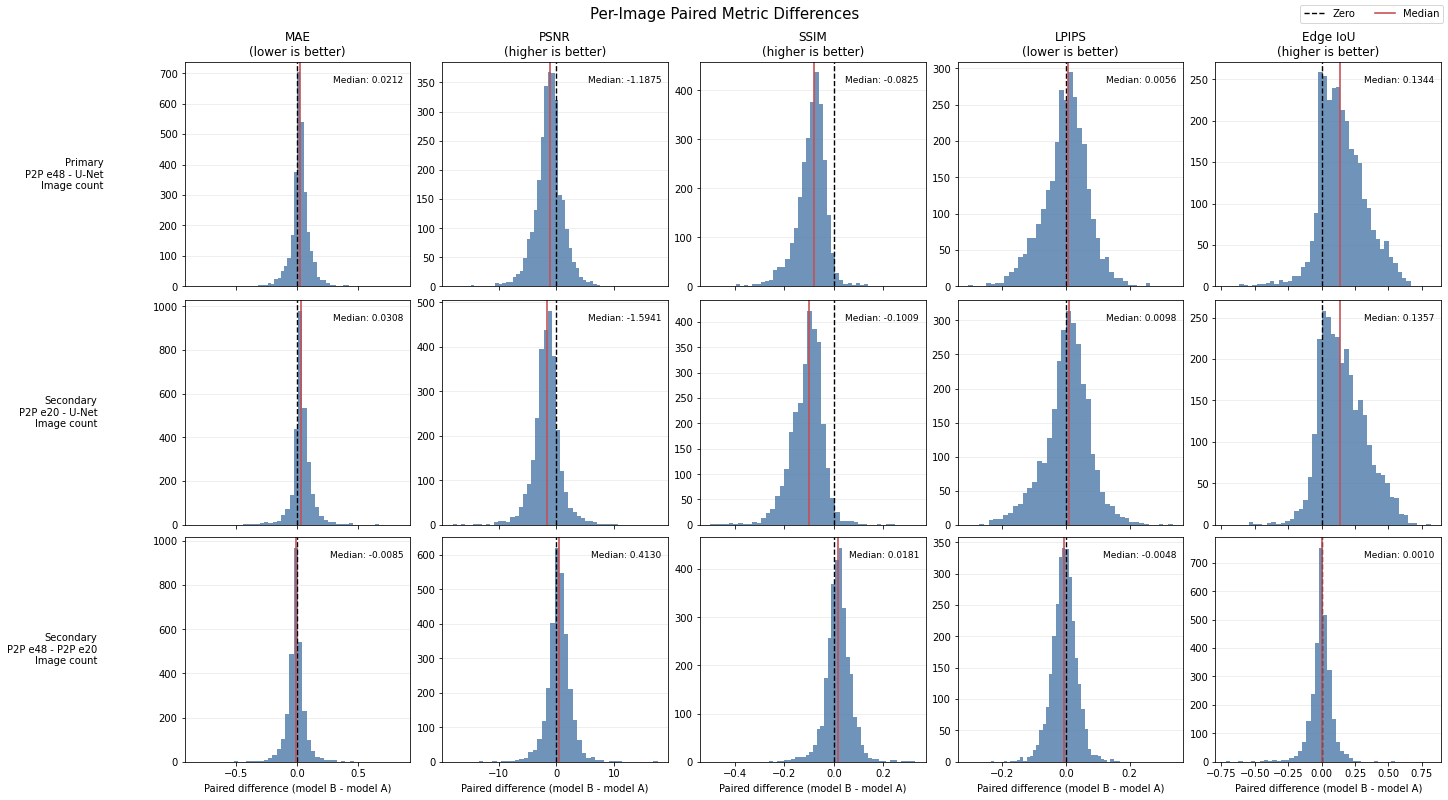

Saved paired-difference figure to: /content/drive/MyDrive/Sketch2Furniture/figures/paired_metric_differences.png


In [25]:
# Visualize Paired Metric Differences

figure, axes = plt.subplots(
    len(model_comparisons),
    len(performance_metric_columns),
    figsize=(20, 11),
    sharex="col",
    constrained_layout=True,
)

for row_index, (
    comparison_role,
    model_a,
    model_b,
) in enumerate(model_comparisons):
    for column_index, metric_name in enumerate(
        performance_metric_columns
    ):
        axis = axes[row_index, column_index]
        differences = (
            paired_metric_tables[metric_name][model_b]
            - paired_metric_tables[metric_name][model_a]
        ).to_numpy()
        median_difference = np.median(differences)

        axis.hist(
            differences,
            bins=40,
            color="#4C78A8",
            alpha=0.8,
        )
        axis.axvline(
            0,
            color="black",
            linestyle="--",
            linewidth=1.4,
            label="Zero",
        )
        axis.axvline(
            median_difference,
            color="#C44E52",
            linewidth=1.6,
            label="Median",
        )
        axis.text(
            0.97,
            0.94,
            f"Median: {median_difference:.4f}",
            transform=axis.transAxes,
            ha="right",
            va="top",
            fontsize=9,
        )
        axis.grid(
            alpha=0.25,
            axis="y",
        )
        axis.set_axisbelow(True)

        if row_index == 0:
            axis.set_title(
                f"{metric_display_names[metric_name]}\n"
                f"({metric_directions[metric_name]})"
            )
        if column_index == 0:
            axis.set_ylabel(
                f"{comparison_role}\n"
                f"{short_model_names[model_b]} - "
                f"{short_model_names[model_a]}\n"
                f"Image count",
                rotation=0,
                ha="right",
                va="center",
                labelpad=55,
            )
        if row_index == len(model_comparisons) - 1:
            axis.set_xlabel("Paired difference (model B - model A)")

handles, labels = (axes[0, 0].get_legend_handles_labels())

figure.suptitle(
    "Per-Image Paired Metric Differences",
    fontsize=15,
)

figure.legend(
    handles,
    labels,
    loc="outside upper right",
    ncol=2,
)

PAIRED_DIFFERENCES_FIGURE_PATH = (FIGURE_DIR / "paired_metric_differences.png")

figure.savefig(
    PAIRED_DIFFERENCES_FIGURE_PATH,
    dpi=150,
)

plt.show()

print(
    f"Saved paired-difference figure to: "
    f"{PAIRED_DIFFERENCES_FIGURE_PATH}"
)

### Observation

The paired analysis confirms that most differences observed in the descriptive results are systematic across the same 2892 test images. In the primary comparison, the reconstruction-only U-Net performs significantly better than Pix2Pix epoch 48 in MAE, PSNR and SSIM, with median paired differences of 0.0212, -1.1875 and -0.0825 respectively for Pix2Pix minus U-Net. Conversely, Pix2Pix epoch 48 achieves a significantly higher edge IoU, with a median improvement of 0.1344. This demonstrates a clear trade-off: the U-Net reconstructs the target photographs more accurately, while Pix2Pix preserves the conditioning-sketch contours more faithfully. The small LPIPS difference of 0.0056 is not significant after Holm correction ($p = 0.1571$), so neither model has a statistically reliable perceptual advantage in this comparison.

The secondary comparison with Pix2Pix epoch 20 follows the same general pattern, although the U-Net is also significantly better in LPIPS. Between the two Pix2Pix checkpoints, epoch 48 significantly improves MAE, PSNR, SSIM and LPIPS, with median differences of -0.0085, 0.4130, 0.0181 and -0.0048 respectively. Their edge-IoU difference is only 0.0010 and is not significant ($p = 0.9294$). Epoch 48 therefore improves reconstruction and perceptual similarity over epoch 20 without materially changing the preservation of the conditioning contours.

Overall, 13 of the 15 tests remain significant after Holm correction. In the two nonsignificant tests, the median and zero lines nearly overlap at the shared plotting scale, while the significant tests generally show clearer median shifts away from zero. The paired-difference distributions extend across both sides of zero, showing that the better model is not superior for every individual image, while their tails indicate a minority of pairs with much larger model differences. The median shifts nevertheless establish consistent overall directions and provide practical context for the very small p-values produced by the large paired test set.

## Per-Category Results

The overall metrics combine both furniture categories and may conceal category-specific differences. To examine whether the model rankings are consistent across furniture types, the following analysis reports the mean and median reconstruction, perceptual and structural metrics separately for beds and dressers. Mean and median input edge density are also included to contextualize whether apparent category differences may be associated with differences in sketch complexity. Because all three models are evaluated using the same conditioning sketches, the edge-density values repeat across models within each category.


In [26]:
# Summarize Results by Furniture Category

category_summary = (
    evaluation_results
    .groupby(
        ["category", "model"],
        as_index=False,
    )
    .agg(
        image_count=("pair_id", "nunique"),
        mae_mean=("mae", "mean"),
        mae_median=("mae", "median"),
        psnr_mean=("psnr", "mean"),
        psnr_median=("psnr", "median"),
        ssim_mean=("ssim", "mean"),
        ssim_median=("ssim", "median"),
        lpips_mean=("lpips", "mean"),
        lpips_median=("lpips", "median"),
        edge_iou_mean=("edge_iou", "mean"),
        edge_iou_median=("edge_iou", "median"),
        edge_density_mean=("edge_density", "mean"),
        edge_density_median=("edge_density", "median"),
    )
)

category_summary["model"] = pd.Categorical(
    category_summary["model"],
    categories=expected_model_names,
    ordered=True,
)

category_summary = (
    category_summary
    .sort_values(["category", "model"])
    .reset_index(drop=True)
)

CATEGORY_RESULTS_PATH = (
    RESULTS_DIR / "per_category_metrics.csv"
)

category_summary.to_csv(
    CATEGORY_RESULTS_PATH,
    index=False,
)

formatted_columns = {
    column: "{:.4f}"
    for column in category_summary.columns
    if column.endswith(("_mean", "_median"))
}

display(
    category_summary.style.format(
        formatted_columns
    )
)

print(
    f"Saved per-category results to: "
    f"{CATEGORY_RESULTS_PATH}"
)

,category,model,image_count,mae_mean,mae_median,psnr_mean,psnr_median,ssim_mean,ssim_median,lpips_mean,lpips_median,edge_iou_mean,edge_iou_median,edge_density_mean,edge_density_median
0,beds,Reconstruction-only U-Net,1310,0.2001,0.1740,16.6363,16.6482,0.7013,0.7098,0.2925,0.2847,0.6958,0.7024,0.0449,0.0396
1,beds,Pix2Pix epoch 20,1310,0.2354,0.2137,15.0605,14.9412,0.6152,0.6266,0.3209,0.3105,0.8443,0.8487,0.0449,0.0396
2,beds,Pix2Pix epoch 48,1310,0.2278,0.2073,15.3911,15.2616,0.6219,0.6313,0.3197,0.3125,0.8357,0.8524,0.0449,0.0396
3,dressers,Reconstruction-only U-Net,1582,0.2299,0.1873,17.2901,17.5545,0.6301,0.6353,0.3841,0.3808,0.6900,0.7179,0.0375,0.0315
4,dressers,Pix2Pix epoch 20,1582,0.2671,0.2276,15.5455,15.5067,0.5022,0.4974,0.3690,0.3621,0.8567,0.8659,0.0375,0.0315
5,dressers,Pix2Pix epoch 48,1582,0.2516,0.2208,16.0187,15.9974,0.5293,0.5294,0.3607,0.3539,0.8554,0.8736,0.0375,0.0315


Saved per-category results to: /content/drive/MyDrive/Sketch2Furniture/results/per_category_metrics.csv


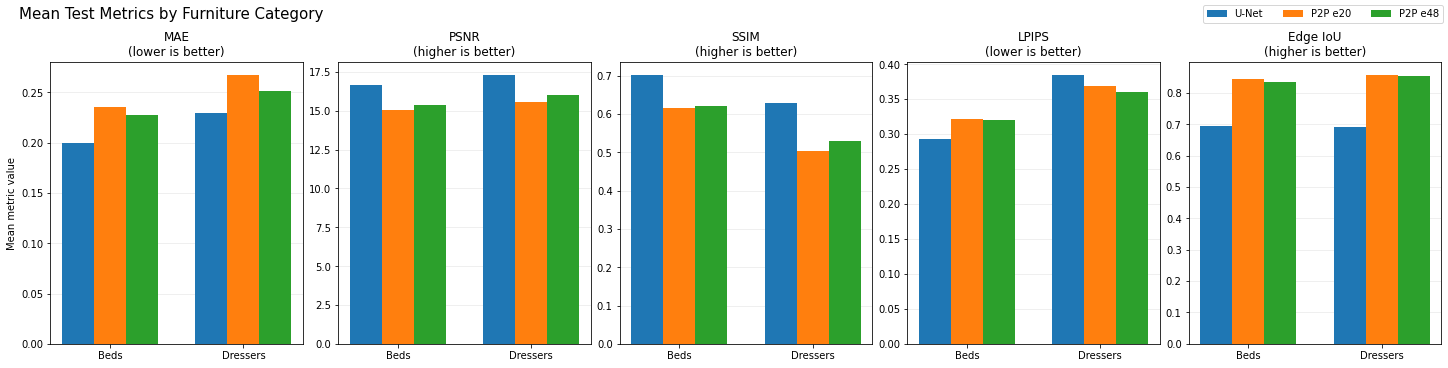

Saved per-category figure to: /content/drive/MyDrive/Sketch2Furniture/figures/per_category_metrics.png


In [27]:
# Visualize Mean Results by Furniture Category

category_names = (
    category_summary["category"]
    .drop_duplicates()
    .tolist()
)

x_positions = np.arange(len(category_names))
bar_width = 0.24

figure, axes = plt.subplots(
    1,
    len(performance_metric_columns),
    figsize=(20, 5),
    constrained_layout=True,
)

for axis, metric_name in zip(
    axes,
    performance_metric_columns,
):
    metric_table = (
        category_summary
        .pivot(
            index="category",
            columns="model",
            values=f"{metric_name}_mean",
        )
        .reindex(
            index=category_names,
            columns=expected_model_names,
        )
    )

    for offset, model_name in zip(
        (-bar_width, 0, bar_width),
        expected_model_names,
    ):
        axis.bar(
            x_positions + offset,
            metric_table[model_name],
            width=bar_width,
            label=short_model_names[model_name],
        )

    axis.set_title(
        f"{metric_display_names[metric_name]}\n"
        f"({metric_directions[metric_name]})"
    )
    axis.set_xticks(
        x_positions,
        [name.title() for name in category_names],
    )
    axis.set_ylim(bottom=0)
    axis.grid(
        axis="y",
        alpha=0.25,
    )
    axis.set_axisbelow(True)

axes[0].set_ylabel("Mean metric value")

handles, labels = axes[0].get_legend_handles_labels()

figure.suptitle(
    "Mean Test Metrics by Furniture Category",
    x=0.01,
    ha="left",
    fontsize=15,
)

figure.legend(
    handles,
    labels,
    loc="outside upper right",
    ncol=3,
)

CATEGORY_FIGURE_PATH = (FIGURE_DIR / "per_category_metrics.png")

figure.savefig(CATEGORY_FIGURE_PATH, dpi=150)

plt.show()

print(
    f"Saved per-category figure to: "
    f"{CATEGORY_FIGURE_PATH}"
)

The category-dependent LPIPS pattern observed in the descriptive results is followed up within each category. This analysis was prompted by the observed results rather than specified in advance, so it is reported as a post-hoc follow-up and corrected within its own family of two tests rather than being included in the earlier family of fifteen. Only the primary comparison between the reconstruction-only U-Net and Pix2Pix epoch 48 is tested, separately for beds and dressers. Paired differences are calculated as Pix2Pix epoch 48 minus U-Net, so positive values favour the U-Net and negative values favour Pix2Pix for LPIPS.


In [28]:
# Test the Primary LPIPS Comparison by Category


PRIMARY_MODEL_A = "Reconstruction-only U-Net"
PRIMARY_MODEL_B = "Pix2Pix epoch 48"

lpips_category_records = []
for category_name in category_names:
    category_pair_ids = evaluation_results.loc[
        evaluation_results["category"] == category_name,
        "pair_id",
    ].unique()
    category_table = (
        paired_metric_tables["lpips"]
        .loc[category_pair_ids]
    )
    differences = (
        category_table[PRIMARY_MODEL_B]
        - category_table[PRIMARY_MODEL_A]
    ).to_numpy()
    test_result = wilcoxon(
        differences,
        alternative="two-sided",
    )
    lpips_category_records.append(
        {
            "category": category_name,
            "n_pairs": len(differences),
            "median_difference": np.median(differences),
            "p_value_raw": test_result.pvalue,
        }
    )

lpips_category_results = pd.DataFrame(
    lpips_category_records
)

reject_h0, p_values_holm = multipletests(
    lpips_category_results["p_value_raw"],
    alpha=0.05,
    method="holm",
)[:2]

lpips_category_results["p_value_holm"] = p_values_holm
lpips_category_results["significant"] = reject_h0

LPIPS_CATEGORY_PATH = (
    RESULTS_DIR / "lpips_category_wilcoxon.csv"
)
lpips_category_results.to_csv(
    LPIPS_CATEGORY_PATH,
    index=False,
)

display(
    lpips_category_results.style.format(
        {
            "median_difference": "{:.4f}",
            "p_value_raw": format_p_value,
            "p_value_holm": format_p_value,
        }
    )
)
print(
    f"Saved per-category LPIPS tests to: "
    f"{LPIPS_CATEGORY_PATH}"
)

,category,n_pairs,median_difference,p_value_raw,p_value_holm,significant
0,beds,1310,0.0226,8.159e-84,1.632e-83,True
1,dressers,1582,-0.0231,1.783e-30,1.783e-30,True


Saved per-category LPIPS tests to: /content/drive/MyDrive/Sketch2Furniture/results/lpips_category_wilcoxon.csv


### Observation

The per-category results preserve the main trade-off observed across the complete test set. The reconstruction-only U-Net achieves the lowest mean MAE and the highest mean PSNR and SSIM for both beds and dressers, whereas both Pix2Pix checkpoints achieve substantially higher edge IoU. Pix2Pix epoch 48 also improves the mean MAE, PSNR, SSIM and LPIPS over epoch 20 within both categories. Their edge-IoU results remain very close, and the mean and median rankings of the two checkpoints reverse, consistent with the earlier finding that their structural difference is not statistically significant.

LPIPS shows the clearest category-dependent result. The U-Net performs best for beds, with a mean LPIPS of 0.2925 compared with 0.3197 for Pix2Pix epoch 48, while for dressers Pix2Pix epoch 48 performs best, with 0.3607 compared with 0.3841. The post-hoc paired tests support both differences after Holm correction, with median paired differences of 0.0226 for beds and -0.0231 for dressers, favouring the U-Net and Pix2Pix epoch 48 respectively. Two effects of comparable magnitude acting in opposite directions help explain why the pooled LPIPS comparison was not significant: the perceptual advantage is consistent within each category, but its direction differs between them.

Beds have higher mean input edge density than dressers, at 0.0449 compared with 0.0375, and also achieve lower MAE and LPIPS and higher SSIM. This pattern is consistent with output quality being associated with the amount of structural information in the conditioning sketch, although PSNR runs counter to it and is higher for dressers across all models. The agreement between most mean and median rankings shows that the principal conclusions are not driven only by extreme observations. However, with only two categories, these comparisons cannot separate an edge-density effect from a category effect, so the relationship is examined per image in the following section.


## Structural Analysis

The previous analyses indicate that model performance may vary with the amount of structural information available in the conditioning sketch. To examine this relationship across the complete test set, Spearman rank correlations are calculated separately for each model between input edge density and MAE, PSNR, SSIM, LPIPS and edge IoU. Spearman correlation is used because it measures monotonic associations without assuming linearity or normally distributed variables.

Computing the correlations separately preserves the 2892 unique image observations for each model and avoids pooling dependent model outputs generated from the same conditioning sketches. Holm correction is applied across the resulting family of fifteen tests. Differences between model coefficients are interpreted descriptively because this analysis does not directly test whether the correlations differ significantly between models.

As a robustness check, the edge-density correlations are subsequently repeated within each furniture category. These within-category tests form a separate family of thirty comparisons - three models × five metrics × two categories - and are therefore corrected independently using the Holm procedure rather than being combined with the primary family of fifteen tests.

Finally, pairwise Spearman correlations among the five evaluation metrics are examined separately for each model. These correlations are used descriptively to assess whether edge IoU captures information that is complementary to the reconstruction and perceptual metrics, helping to interpret the different model rankings observed across MAE, PSNR, SSIM, LPIPS and edge IoU.


In [29]:
# Correlate Edge Density with Performance by Model


structural_expected_pair_ids = set(
    evaluation_results["pair_id"].unique()
)

spearman_records = []

for model_name in expected_model_names:
    model_results = (
        evaluation_results.loc[
            evaluation_results["model"] == model_name,
            [
                "pair_id",
                "edge_density",
                *performance_metric_columns,
            ],
        ]
        .copy()
    )

    if model_results["pair_id"].duplicated().any():
        raise ValueError(
            f"Duplicate pair IDs found for {model_name}."
        )

    if set(model_results["pair_id"]) != (
        structural_expected_pair_ids
    ):
        raise ValueError(
            f"Pair-ID coverage is incomplete for {model_name}."
        )

    if model_results[
        ["edge_density", *performance_metric_columns]
    ].isna().any().any():
        raise ValueError(
            f"Missing structural-analysis values for "
            f"{model_name}."
        )

    for metric_name in performance_metric_columns:
        test_result = spearmanr(
            model_results["edge_density"],
            model_results[metric_name],
        )

        spearman_records.append(
            {
                "model": model_name,
                "metric": metric_name,
                "n_images": len(model_results),
                "spearman_rho": test_result.statistic,
                "p_value_raw": test_result.pvalue,
            }
        )

spearman_results = pd.DataFrame(spearman_records)

reject_h0, p_values_holm = multipletests(
    spearman_results["p_value_raw"],
    alpha=0.05,
    method="holm",
)[:2]

spearman_results["p_value_holm"] = p_values_holm
spearman_results["significant"] = reject_h0

spearman_results["model"] = pd.Categorical(
    spearman_results["model"],
    categories=expected_model_names,
    ordered=True,
)

spearman_results["metric"] = pd.Categorical(
    spearman_results["metric"],
    categories=performance_metric_columns,
    ordered=True,
)

spearman_results = (
    spearman_results
    .sort_values(["model", "metric"])
    .reset_index(drop=True)
)

SPEARMAN_RESULTS_PATH = (RESULTS_DIR / "edge_density_spearman.csv")

spearman_results.to_csv(SPEARMAN_RESULTS_PATH, index=False)

spearman_display = spearman_results.copy()

spearman_display["model"] = [
    short_model_names[str(model_name)]
    for model_name in spearman_display["model"]
]

spearman_display["metric"] = [
    metric_display_names[str(metric_name)]
    for metric_name in spearman_display["metric"]
]

display(
    spearman_display.style.format(
        {
            "spearman_rho": "{:.4f}",
            "p_value_raw": format_p_value,
            "p_value_holm": format_p_value,
        }
    )
)

print(
    f"Saved edge-density correlations to: "
    f"{SPEARMAN_RESULTS_PATH}"
)

,model,metric,n_images,spearman_rho,p_value_raw,p_value_holm,significant
0,U-Net,MAE,2892,0.3529,1.404e-85,1.263e-84,True
1,U-Net,PSNR,2892,-0.4049,1.651e-114,1.651e-113,True
2,U-Net,SSIM,2892,-0.3351,7.879e-77,5.515e-76,True
3,U-Net,LPIPS,2892,-0.2724,2.154e-50,1.077e-49,True
4,U-Net,Edge IoU,2892,-0.5478,3.697e-226,5.545e-225,True
5,P2P e20,MAE,2892,0.4092,3.704e-117,4.075e-116,True
6,P2P e20,PSNR,2892,-0.4750,9.873e-163,1.284e-161,True
7,P2P e20,SSIM,2892,-0.2318,1.354e-36,4.061e-36,True
8,P2P e20,LPIPS,2892,-0.1961,1.801e-26,3.601e-26,True
9,P2P e20,Edge IoU,2892,-0.3357,4.215e-77,3.372e-76,True


Saved edge-density correlations to: /content/drive/MyDrive/Sketch2Furniture/results/edge_density_spearman.csv


### Visualize Edge-Density Correlations by Model

The Holm-corrected model-specific correlations are visualized to compare their direction and magnitude across the five evaluation metrics. Positive coefficients indicate that metric values tend to increase with edge density, whereas negative coefficients indicate that they tend to decrease.

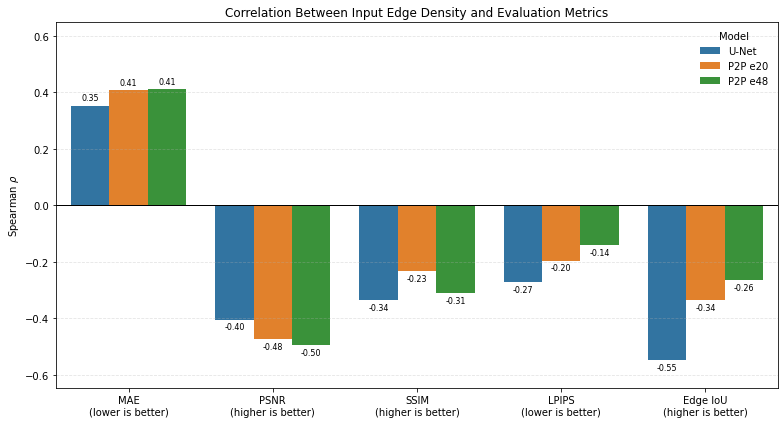

Saved edge-density correlation figure to: /content/drive/MyDrive/Sketch2Furniture/figures/edge_density_spearman.png


In [33]:
# Visualize the model-specific edge-density correlations

spearman_plot = spearman_results.copy()

spearman_plot["model"] = [
    short_model_names[str(model_name)]
    for model_name in spearman_plot["model"]
]

spearman_plot["metric"] = [
    f"{metric_display_names[str(metric_name)]}\n"
    f"({metric_directions[str(metric_name)]})"
    for metric_name in spearman_plot["metric"]
]

model_display_order = [
    short_model_names[model_name]
    for model_name in expected_model_names
]

metric_display_order = [
    f"{metric_display_names[metric_name]}\n"
    f"({metric_directions[metric_name]})"
    for metric_name in performance_metric_columns
]

matplotlib_colors = (
    plt.rcParams["axes.prop_cycle"]
    .by_key()["color"]
)

structural_palette = dict(
    zip(
        model_display_order,
        matplotlib_colors[:len(model_display_order)],
    )
)

figure, axis = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=spearman_plot,
    x="metric",
    y="spearman_rho",
    hue="model",
    order=metric_display_order,
    hue_order=model_display_order,
    palette=structural_palette,
    errorbar=None,
    ax=axis,
)

axis.axhline(
    0,
    color="black",
    linewidth=1,
)

rho_limit = min(
    1.0,
    spearman_plot["spearman_rho"].abs().max() + 0.10,
)

axis.set_ylim(-rho_limit, rho_limit)
axis.set_xlabel("")
axis.set_ylabel(r"Spearman $\rho$")
axis.set_title(
    "Correlation Between Input Edge Density "
    "and Evaluation Metrics"
)

axis.grid(
    axis="y",
    linestyle="--",
    alpha=0.35,
)

axis.legend(
    title="Model",
    frameon=False,
    loc="upper right",
)

for container in axis.containers:
    axis.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=8,
    )

figure.tight_layout()

EDGE_DENSITY_SPEARMAN_FIGURE_PATH = (
    FIGURE_DIR / "edge_density_spearman.png"
)

figure.savefig(
    EDGE_DENSITY_SPEARMAN_FIGURE_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved edge-density correlation figure to: "
    f"{EDGE_DENSITY_SPEARMAN_FIGURE_PATH}"
)

### Correlate Edge Density with Evaluation Metrics Within Each Category

As a robustness check, the model-specific Spearman correlations are repeated separately for beds and dressers. This determines whether the associations observed across the complete test set remain within each furniture category rather than being driven mainly by differences between their edge-density distributions. The resulting thirty tests form a separate family and receive their own Holm correction.

In [34]:
# Calculate edge-density correlations within each category

structural_category_order = (
    evaluation_results["category"]
    .drop_duplicates()
    .tolist()
)

within_category_records = []
for category_name in structural_category_order:
    for model_name in expected_model_names:
        subset = evaluation_results.loc[
            (evaluation_results["category"] == category_name)
            & (evaluation_results["model"] == model_name)
        ]
        for metric_name in performance_metric_columns:
            test_result = spearmanr(
                subset["edge_density"],
                subset[metric_name],
            )
            within_category_records.append(
                {
                    "category": category_name,
                    "model": model_name,
                    "metric": metric_name,
                    "n_images": len(subset),
                    "spearman_rho": test_result.statistic,
                    "p_value_raw": test_result.pvalue,
                }
            )

within_category_spearman_results = pd.DataFrame(
    within_category_records
)

if len(within_category_spearman_results) != 30:
    raise ValueError(
        "Expected 30 within-category tests, found "
        f"{len(within_category_spearman_results)}."
    )

reject_h0, p_values_holm = multipletests(
    within_category_spearman_results["p_value_raw"],
    alpha=0.05,
    method="holm",
)[:2]

within_category_spearman_results["p_value_holm"] = p_values_holm
within_category_spearman_results["significant"] = reject_h0

WITHIN_CATEGORY_SPEARMAN_RESULTS_PATH = (
    RESULTS_DIR
    / "edge_density_spearman_by_category.csv"
)
within_category_spearman_results.to_csv(
    WITHIN_CATEGORY_SPEARMAN_RESULTS_PATH,
    index=False,
)

within_category_display = (within_category_spearman_results.copy())

within_category_display["category"] = (
    within_category_display["category"].str.title()
)

within_category_display["model"] = (
    within_category_display["model"]
    .map(short_model_names)
)
within_category_display["metric"] = (
    within_category_display["metric"]
    .map(metric_display_names)
)

display(
    within_category_display.style.format(
        {
            "spearman_rho": "{:.4f}",
            "p_value_raw": format_p_value,
            "p_value_holm": format_p_value,
        }
    )
)
print(
    f"Saved within-category correlations to: "
    f"{WITHIN_CATEGORY_SPEARMAN_RESULTS_PATH}"
)

,category,model,metric,n_images,spearman_rho,p_value_raw,p_value_holm,significant
0,Beds,U-Net,MAE,1310,0.3331,2.538e-35,2.284e-34,True
1,Beds,U-Net,PSNR,1310,-0.3679,2.935e-43,2.935e-42,True
2,Beds,U-Net,SSIM,1310,-0.4504,1.976e-66,4.158e-65,True
3,Beds,U-Net,LPIPS,1310,-0.1337,1.192e-06,4.768e-06,True
4,Beds,U-Net,Edge IoU,1310,-0.3795,3.866e-46,4.252e-45,True
5,Beds,P2P e20,MAE,1310,0.3940,6.599e-50,8.578e-49,True
6,Beds,P2P e20,PSNR,1310,-0.4504,1.890e-66,4.158e-65,True
7,Beds,P2P e20,SSIM,1310,-0.4016,6.220e-52,8.709e-51,True
8,Beds,P2P e20,LPIPS,1310,-0.2727,8.943e-24,6.260e-23,True
9,Beds,P2P e20,Edge IoU,1310,-0.2125,7.677e-15,4.606e-14,True


Saved within-category correlations to: /content/drive/MyDrive/Sketch2Furniture/results/edge_density_spearman_by_category.csv


### Correlate Evaluation Metrics by Model

Pairwise Spearman correlations are calculated among the five evaluation metrics separately for each model. These matrices are examined descriptively and therefore report correlation coefficients without p-values or multiple-testing correction. Because lower values are preferable for MAE and LPIPS whereas higher values are preferable for PSNR, SSIM and edge IoU, coefficient signs are interpreted together with the direction of each metric.

In [35]:
# Calculate pairwise metric correlations for each model

metric_spearman_matrices = {}

for model_name in expected_model_names:
    model_metric_values = evaluation_results.loc[
        evaluation_results["model"] == model_name,
        performance_metric_columns,
    ]

    if (
        model_metric_values.empty
        or model_metric_values.isna().any().any()
    ):
        raise ValueError(
            f"Missing metric observations for {model_name}."
        )

    metric_spearman_matrices[model_name] = (
        model_metric_values
        .corr(method="spearman")
        .loc[
            performance_metric_columns,
            performance_metric_columns,
        ]
    )

metric_spearman_results = pd.concat(
    metric_spearman_matrices,
    names=["model", "metric"],
)

METRIC_SPEARMAN_RESULTS_PATH = (
    RESULTS_DIR / "metric_spearman_by_model.csv"
)

metric_spearman_results.to_csv(
    METRIC_SPEARMAN_RESULTS_PATH
)

print(
    f"Saved metric correlations to: "
    f"{METRIC_SPEARMAN_RESULTS_PATH}"
)

Saved metric correlations to: /content/drive/MyDrive/Sketch2Furniture/results/metric_spearman_by_model.csv


### Visualize Metric Correlations by Model

The model-specific metric correlations are visualized using a common colour scale from -1 to 1. Red cells indicate positive associations and blue cells indicate negative associations. The metric directions are included in the labels because the interpretation of each coefficient depends on whether higher or lower values are preferable.

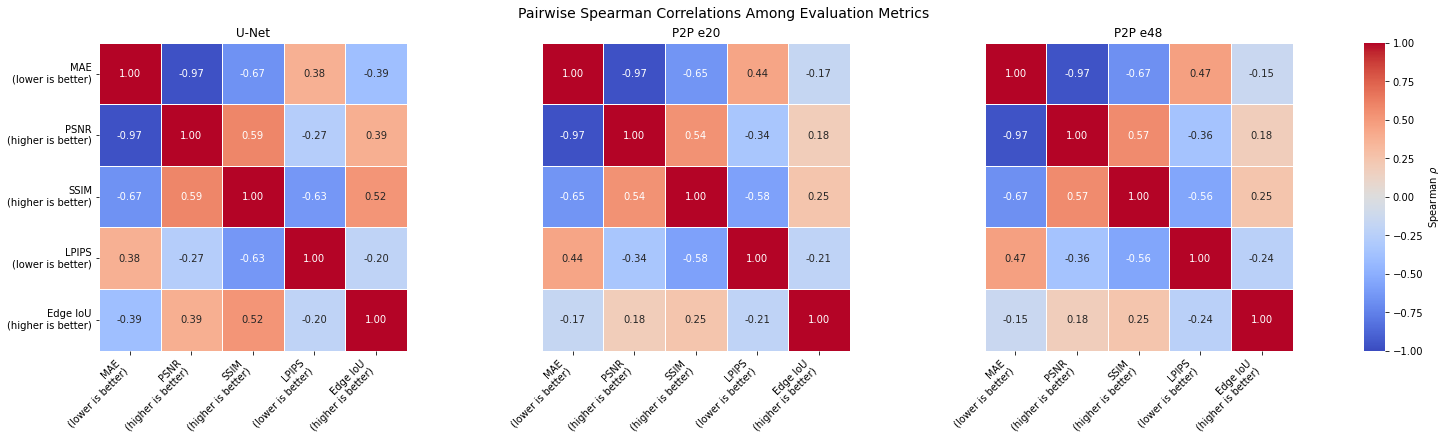

Saved metric correlation heatmaps to: /content/drive/MyDrive/Sketch2Furniture/figures/metric_spearman_heatmaps.png


In [38]:
# Visualize pairwise metric correlations for each model

metric_heatmap_labels = [
    f"{metric_display_names[metric_name]}\n"
    f"({metric_directions[metric_name]})"
    for metric_name in performance_metric_columns
]

figure = plt.figure(
    figsize=(20, 6),
    constrained_layout=True,
)

grid = figure.add_gridspec(
    nrows=1,
    ncols=4,
    width_ratios=[1, 1, 1, 0.05],
)

axes = [
    figure.add_subplot(grid[0, index])
    for index in range(len(expected_model_names))
]

colorbar_axis = figure.add_subplot(grid[0, 3])

for model_index, (model_name, axis) in enumerate(
    zip(expected_model_names, axes)
):
    metric_matrix = (
        metric_spearman_matrices[model_name]
        .copy()
    )

    metric_matrix.index = metric_heatmap_labels
    metric_matrix.columns = metric_heatmap_labels

    sns.heatmap(
        metric_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=0.5,
        linecolor="white",
        cbar=model_index == 0,
        cbar_ax=(
            colorbar_axis
            if model_index == 0
            else None
        ),
        cbar_kws={
            "label": r"Spearman $\rho$",
        },
        ax=axis,
    )

    axis.set_title(short_model_names[model_name])
    axis.set_xlabel("")
    axis.set_ylabel("")

    axis.set_xticklabels(
        axis.get_xticklabels(),
        rotation=45,
        ha="right",
    )

    axis.set_yticklabels(
        axis.get_yticklabels(),
        rotation=0,
    )

    if model_index > 0:
        axis.set_yticklabels([])
        axis.tick_params(
            axis="y",
            left=False,
        )

figure.suptitle(
    "Pairwise Spearman Correlations "
    "Among Evaluation Metrics",
    fontsize=14,
)

METRIC_SPEARMAN_HEATMAP_PATH = (
    FIGURE_DIR / "metric_spearman_heatmaps.png"
)

figure.savefig(
    METRIC_SPEARMAN_HEATMAP_PATH,
    dpi=150,
)

plt.show()

print(
    f"Saved metric correlation heatmaps to: "
    f"{METRIC_SPEARMAN_HEATMAP_PATH}"
)

### Visualize Edge Density Against Round-Trip Edge IoU

To examine the shape of the negative relationship between input edge density and round-trip edge IoU, the image-level observations are visualized separately for each model. Decile medians summarize the trend while helping to reveal whether the correlations represent gradual deterioration or are driven mainly by a restricted range of edge-density values.

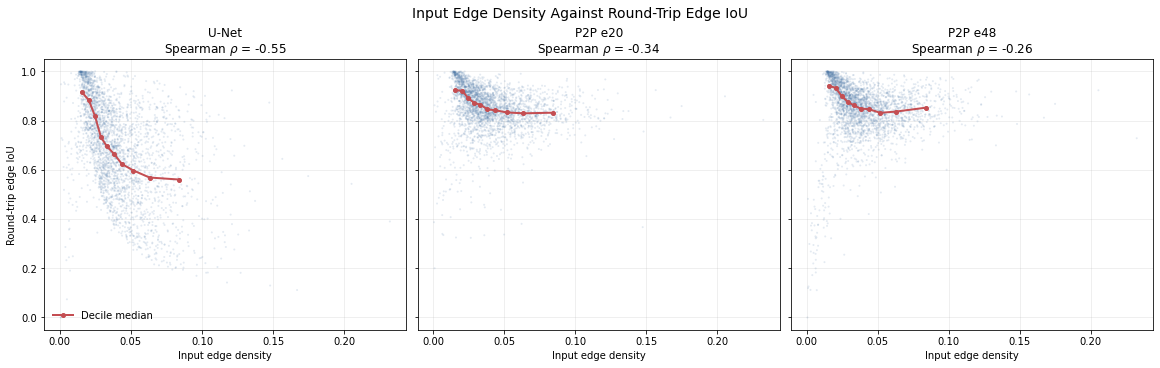

Saved edge-density scatter to: /content/drive/MyDrive/Sketch2Furniture/figures/edge_density_vs_edge_iou.png


In [39]:
# Visualize Edge Density Against Round-Trip Edge IoU

figure, axes = plt.subplots(
    1,
    len(expected_model_names),
    figsize=(16, 5),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for axis, model_name in zip(axes, expected_model_names):
    model_results = evaluation_results.loc[
        evaluation_results["model"] == model_name
    ]
    axis.scatter(
        model_results["edge_density"],
        model_results["edge_iou"],
        s=4,
        alpha=0.15,
        color="#4C78A8",
        edgecolors="none",
    )
    binned_medians = (
        model_results
        .assign(
            density_bin=pd.qcut(
                model_results["edge_density"],
                q=10,
                duplicates="drop",
            )
        )
        .groupby("density_bin", observed=True)
        .agg(
            density=("edge_density", "median"),
            edge_iou=("edge_iou", "median"),
        )
    )
    axis.plot(
        binned_medians["density"],
        binned_medians["edge_iou"],
        color="#C44E52",
        linewidth=2,
        marker="o",
        markersize=4,
        label="Decile median",
    )
    rho = spearman_results.loc[
        (spearman_results["model"] == model_name)
        & (spearman_results["metric"] == "edge_iou"),
        "spearman_rho",
    ].iloc[0]
    axis.set_title(
        f"{short_model_names[model_name]}\n"
        rf"Spearman $\rho$ = {rho:.2f}"
    )
    axis.set_xlabel("Input edge density")
    axis.grid(alpha=0.25)
    axis.set_axisbelow(True)

axes[0].set_ylabel("Round-trip edge IoU")
axes[0].legend(frameon=False, loc="lower left")

figure.suptitle(
    "Input Edge Density Against Round-Trip Edge IoU",
    fontsize=14,
)

EDGE_DENSITY_SCATTER_PATH = (
    FIGURE_DIR / "edge_density_vs_edge_iou.png"
)
figure.savefig(
    EDGE_DENSITY_SCATTER_PATH,
    dpi=150,
)

plt.show()

print(
    f"Saved edge-density scatter to: "
    f"{EDGE_DENSITY_SCATTER_PATH}"
)

### Observation

Input edge density is significantly associated with every metric for all three models, with consistent directions: denser sketches are associated with higher MAE and lower PSNR, SSIM and edge IoU, while LPIPS improves. Absolute coefficients range from 0.14 to 0.55. Edge density most plausibly acts as a proxy for the visual complexity of the source photograph, which is harder to reconstruct pixel by pixel. A plain object produces both a sparse sketch and a largely uniform target, so a featureless output can still achieve a low reconstruction error, as observed for `pair_05659`. LPIPS is the only metric that improves with density, consistent with the Notebook 04 finding that sparse inputs can produce perceptually poor outputs despite favourable pixel scores.

Within categories, all eighteen MAE, PSNR and SSIM tests remain significant with comparable coefficients, showing that these relationships are not solely produced by the differing edge-density distributions of beds and dressers. Only three of the thirty tests are not significant, all involving Pix2Pix: edge IoU for epoch 48 on beds and LPIPS for both Pix2Pix checkpoints on dressers.

The edge-IoU relationship is not uniform across the density range. In the sparsest decile, all three models reach median values of approximately 0.91 to 0.94. By an edge density of 0.085, however, the U-Net median falls to approximately 0.56 while both Pix2Pix curves flatten above 0.82. The Pix2Pix advantage therefore emerges as conditioning sketches become more complex rather than applying uniformly. The U-Net's edge-IoU association is also strongly category-dependent, changing from -0.3795 for beds to -0.6745 for dressers.

The metric correlations show that the five measures are not equally distinct. MAE and PSNR rank the images almost identically at -0.97 and are therefore largely redundant. Edge IoU is comparatively distinct, correlating weakly with the other metrics for both Pix2Pix checkpoints, while showing stronger relationships with MAE, PSNR and SSIM for the U-Net. This explains the earlier model-level result as a trade-off rather than a contradiction: preserving the contours supplied by the conditioning sketch and reproducing the exact target photograph are related but distinct objectives.

## Qualitative Comparison

The qualitative comparison combines six selection-independent test examples with four examples selected from the per-image evaluation results. The first set is chosen at evenly spaced dataset indices using the same procedure as in Notebooks 03 and 04, preserving continuity of selection method while keeping the present analysis entirely within the test split. The diagnostic set contains the bed and dresser with the largest cross-model range in edge IoU and LPIPS. These metric-selected examples represent diagnostic extremes rather than typical model behaviour.

In [40]:
# Select fixed and diagnostic qualitative examples

FIXED_EXAMPLE_COUNT = 6
DIAGNOSTIC_METRICS = ("edge_iou", "lpips")

fixed_example_indices = (
    torch.linspace(
        0,
        len(test_metadata) - 1,
        steps=FIXED_EXAMPLE_COUNT,
    )
    .round()
    .to(torch.int64)
    .tolist()
)

fixed_test_examples = (
    test_metadata
    .iloc[fixed_example_indices][["pair_id", "category"]]
    .reset_index(drop=True)
)
fixed_test_examples.insert(
    0,
    "dataset_index",
    fixed_example_indices,
)

FIXED_QUALITATIVE_RESULTS_PATH = (
    RESULTS_DIR / "qualitative_fixed_test_examples.csv"
)
fixed_test_examples.to_csv(
    FIXED_QUALITATIVE_RESULTS_PATH,
    index=False,
)

# Calculate cross-model metric ranges
diagnostic_ranges = (
    evaluation_results
    .groupby(["pair_id", "category"], observed=True)
    .agg(
        n_models=("model", "nunique"),
        edge_iou_min=("edge_iou", "min"),
        edge_iou_max=("edge_iou", "max"),
        lpips_min=("lpips", "min"),
        lpips_max=("lpips", "max"),
    )
    .reset_index()
)

if not diagnostic_ranges["n_models"].eq(
    len(expected_model_names)
).all():
    raise ValueError(
        "Some pairs do not contain results for every model."
    )

for metric_name in DIAGNOSTIC_METRICS:
    diagnostic_ranges[f"{metric_name}_range"] = (
        diagnostic_ranges[f"{metric_name}_max"]
        - diagnostic_ranges[f"{metric_name}_min"]
    )

# Select four unique diagnostic examples
diagnostic_records = []
selected_pair_ids = set()

for metric_name in DIAGNOSTIC_METRICS:
    for category_name in structural_category_order:
        candidate = (
            diagnostic_ranges.loc[
                (diagnostic_ranges["category"] == category_name)
                & (
                    ~diagnostic_ranges["pair_id"].isin(
                        selected_pair_ids
                    )
                )
            ]
            .sort_values(
                [f"{metric_name}_range", "pair_id"],
                ascending=[False, True],
            )
            .iloc[0]
        )
        diagnostic_records.append(
            {
                "pair_id": candidate["pair_id"],
                "category": category_name,
                "selection_metric": metric_name,
                "metric_min": candidate[f"{metric_name}_min"],
                "metric_max": candidate[f"{metric_name}_max"],
                "metric_range": candidate[f"{metric_name}_range"],
            }
        )
        selected_pair_ids.add(candidate["pair_id"])

diagnostic_examples = pd.DataFrame(diagnostic_records)

if diagnostic_examples["pair_id"].nunique() != 4:
    raise ValueError(
        "Expected four unique diagnostic examples."
    )

QUALITATIVE_DIAGNOSTIC_RESULTS_PATH = (
    RESULTS_DIR / "qualitative_diagnostic_examples.csv"
)
diagnostic_examples.to_csv(
    QUALITATIVE_DIAGNOSTIC_RESULTS_PATH,
    index=False,
)

diagnostic_display = diagnostic_examples.copy()
diagnostic_display["category"] = (
    diagnostic_display["category"].str.title()
)
diagnostic_display["selection_metric"] = (
    diagnostic_display["selection_metric"]
    .map(metric_display_names)
)

display(
    fixed_test_examples.assign(
        category=fixed_test_examples["category"].str.title()
    )
)
display(
    diagnostic_display.style.format(
        {
            "metric_min": "{:.4f}",
            "metric_max": "{:.4f}",
            "metric_range": "{:.4f}",
        }
    )
)

print(
    "Fixed examples per category: "
    f"{fixed_test_examples['category'].value_counts().to_dict()}"
)
print(
    f"Saved fixed example selection to: "
    f"{FIXED_QUALITATIVE_RESULTS_PATH}"
)
print(
    f"Saved diagnostic example selection to: "
    f"{QUALITATIVE_DIAGNOSTIC_RESULTS_PATH}"
)

,dataset_index,pair_id,category
0,0,pair_00008,Beds
1,578,pair_02849,Beds
2,1156,pair_05748,Beds
3,1735,pair_08709,Dressers
4,2313,pair_11490,Dressers
5,2891,pair_14324,Dressers


,pair_id,category,selection_metric,metric_min,metric_max,metric_range
0,pair_04679,Beds,Edge IoU,0.1815,0.8146,0.6331
1,pair_09797,Dressers,Edge IoU,0.0738,0.8917,0.8179
2,pair_03561,Beds,LPIPS,0.1821,0.4477,0.2657
3,pair_09958,Dressers,LPIPS,0.2571,0.5946,0.3374


Fixed examples per category: {'beds': 3, 'dressers': 3}
Saved fixed example selection to: /content/drive/MyDrive/Sketch2Furniture/results/qualitative_fixed_test_examples.csv
Saved diagnostic example selection to: /content/drive/MyDrive/Sketch2Furniture/results/qualitative_diagnostic_examples.csv


In [46]:
# Render Qualitative Comparison Figures

pair_id_to_index = {
    pair_id: index
    for index, pair_id in enumerate(test_metadata["pair_id"])
}


def render_qualitative_figure(
    pair_ids,
    row_labels,
    title,
    output_path,
    annotation_metric=None,
):
    samples = [
        test_dataset[pair_id_to_index[pair_id]]
        for pair_id in pair_ids
    ]
    inputs = torch.stack(
        [sample["input"] for sample in samples]
    ).to(DEVICE)
    targets = torch.stack(
        [sample["target"] for sample in samples]
    )

    with torch.inference_mode():
        predictions = {
            model_name: generators[model_name](inputs)
            .detach()
            .cpu()
            for model_name in expected_model_names
        }

    titles = (
        "Edge Sketch",
        *(
            short_model_names[model_name]
            for model_name in expected_model_names
        ),
        "Target Image",
    )

    figure, axes = plt.subplots(
        len(pair_ids),
        5,
        figsize=(16, 3.4 * len(pair_ids)),
        squeeze=False,
    )

    for row, pair_id in enumerate(pair_ids):
        columns = (
            inputs[row],
            *(
                predictions[model_name][row]
                for model_name in expected_model_names
            ),
            targets[row],
        )
        for column, image in enumerate(columns):
            axis = axes[row, column]
            show_image(axis, image)
            if row == 0:
                axis.set_title(titles[column])
            if (
                annotation_metric is not None
                and 1 <= column <= len(expected_model_names)
            ):
                model_name = expected_model_names[column - 1]
                value = evaluation_results.loc[
                    (evaluation_results["pair_id"] == pair_id)
                    & (evaluation_results["model"] == model_name),
                    annotation_metric,
                ].iloc[0]
                axis.set_xlabel(
                    f"{metric_display_names[annotation_metric]}"
                    f" = {value:.3f}",
                    fontsize=9,
                )
                axis.set_xticks([])
                axis.set_yticks([])
                axis.axis("on")
        axes[row, 0].set_ylabel(
            row_labels[row],
            rotation=0,
            ha="right",
            va="center",
            fontsize=9,
            labelpad=10,
        )
        axes[row, 0].axis("on")
        axes[row, 0].set_xticks([])
        axes[row, 0].set_yticks([])

    for axis in axes.flat:
        for spine in axis.spines.values():
            spine.set_visible(False)

    figure.suptitle(title, fontsize=14)
    plt.tight_layout()
    figure.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved figure to: {output_path}")

In [47]:
def show_image(axis, image):
    array = (
        image.detach()
        .cpu()
        .add(1)
        .div(2)
        .clamp(0, 1)
        .permute(1, 2, 0)
        .numpy()
    )
    if array.shape[-1] == 1:
        axis.imshow(
            array.squeeze(-1),
            cmap="gray",
            vmin=0,
            vmax=1,
        )
    else:
        axis.imshow(array)
    axis.axis("off")

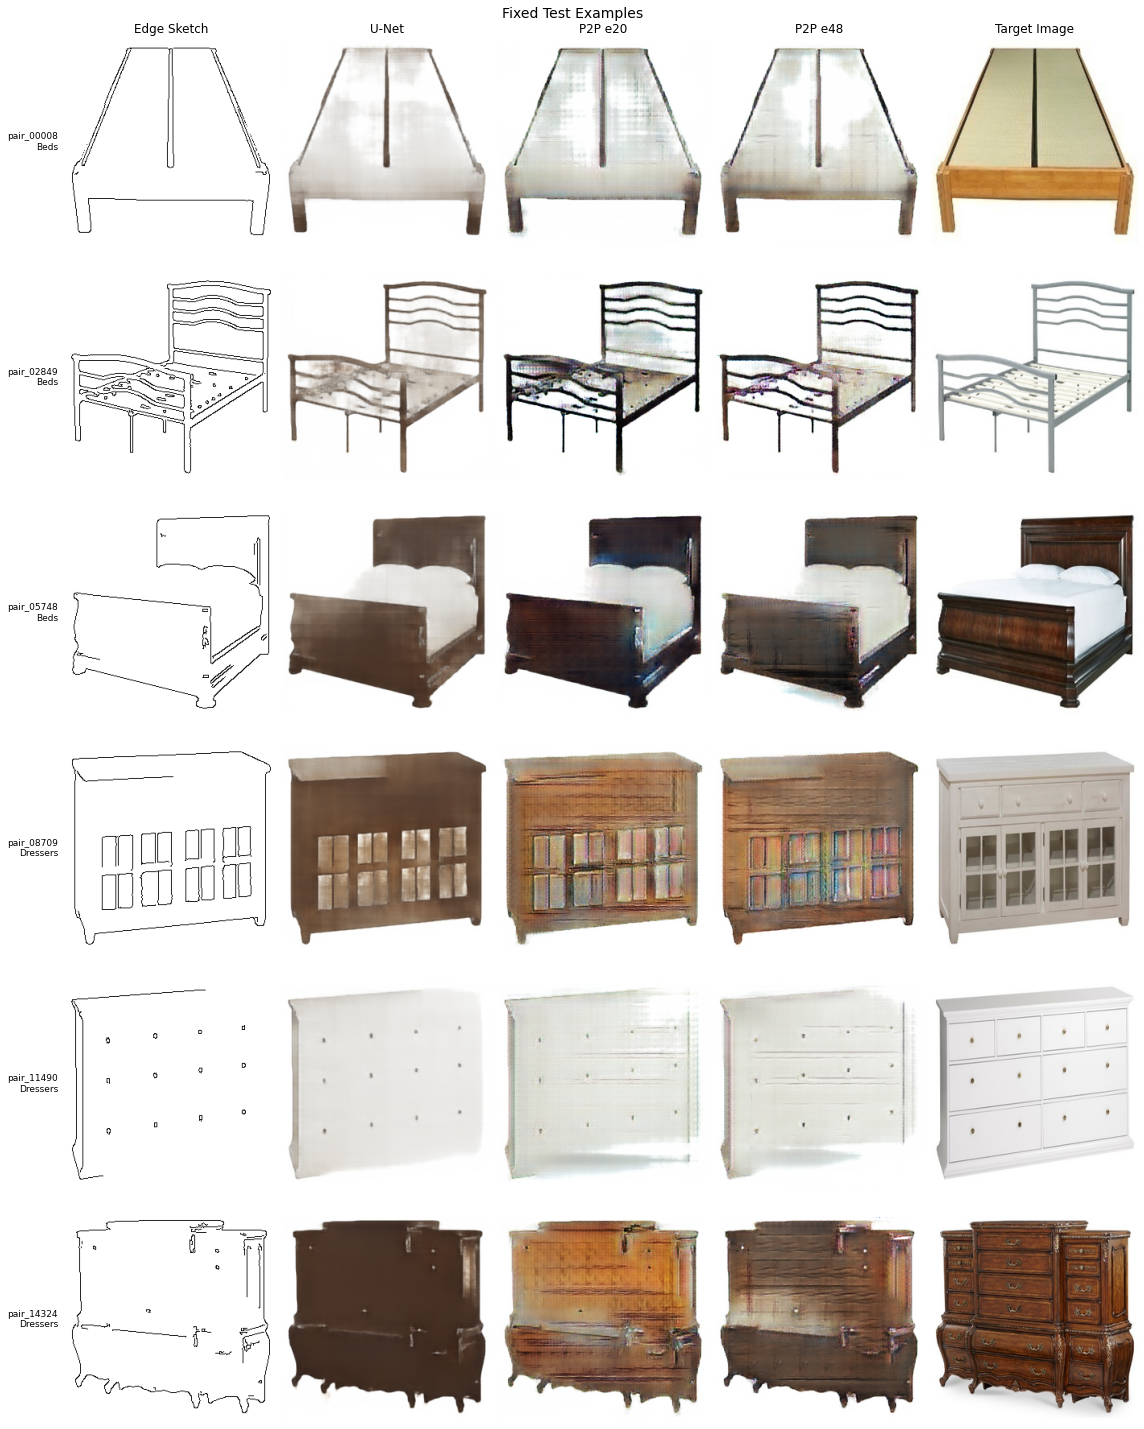

Saved figure to: /content/drive/MyDrive/Sketch2Furniture/figures/qualitative_fixed_examples.png


In [48]:
render_qualitative_figure(
    pair_ids=fixed_test_examples["pair_id"].tolist(),
    row_labels=[
        f"{row.pair_id}\n{row.category.title()}"
        for row in fixed_test_examples.itertuples()
    ],
    title="Fixed Test Examples",
    output_path=FIGURE_DIR / "qualitative_fixed_examples.png",
)

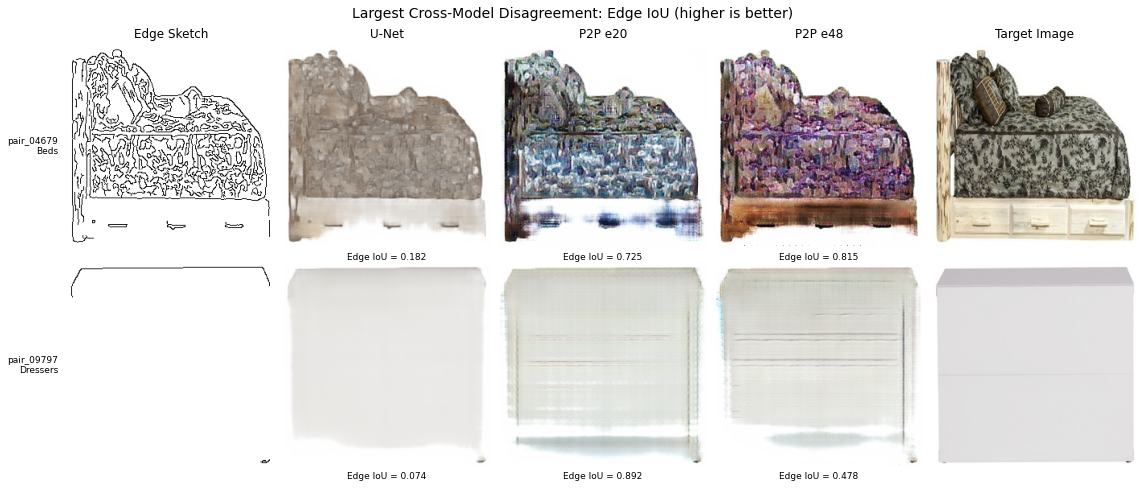

Saved figure to: /content/drive/MyDrive/Sketch2Furniture/figures/qualitative_disagreement_edge_iou.png


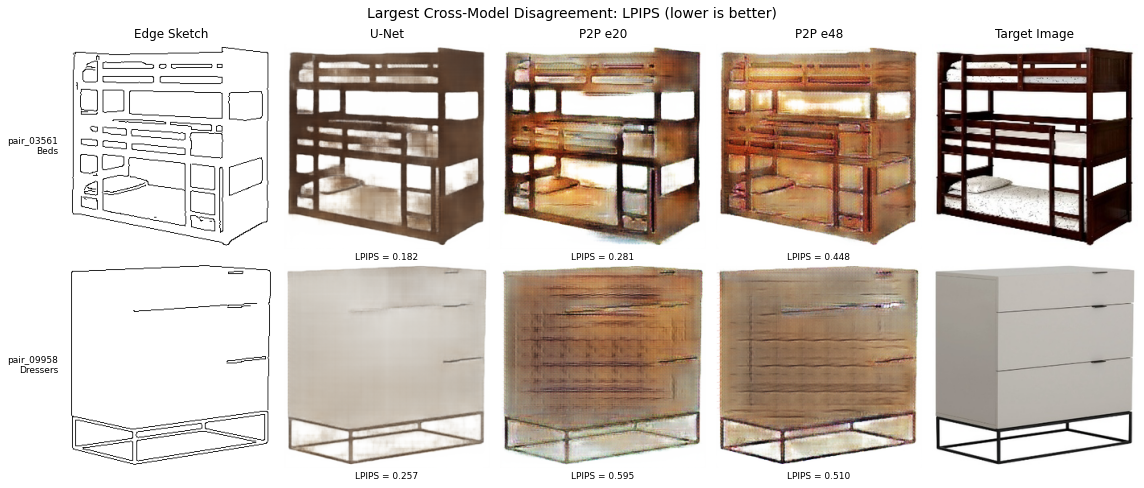

Saved figure to: /content/drive/MyDrive/Sketch2Furniture/figures/qualitative_disagreement_lpips.png


In [49]:
for metric_name in DIAGNOSTIC_METRICS:
    subset = diagnostic_examples.loc[
        diagnostic_examples["selection_metric"] == metric_name
    ]
    render_qualitative_figure(
        pair_ids=subset["pair_id"].tolist(),
        row_labels=[
            f"{row.pair_id}\n{row.category.title()}"
            for row in subset.itertuples()
        ],
        title=(
            "Largest Cross-Model Disagreement: "
            f"{metric_display_names[metric_name]} "
            f"({metric_directions[metric_name]})"
        ),
        output_path=(
            FIGURE_DIR
            / f"qualitative_disagreement_{metric_name}.png"
        ),
        annotation_metric=metric_name,
    )

### Observation

Although category was not used to select the fixed examples, the evenly spaced indices happened to produce three beds and three dressers. Across these selection-independent cases, the U-Net generally produces smoother reconstructions, while Pix2Pix preserves sharper contours but often introduces colour and texture artefacts. None of the models consistently recovers appearance details that are absent from the sketch.

The Edge-IoU examples demonstrate the structural advantage of Pix2Pix. For `pair_04679`, Edge IoU rises from 0.182 for the U-Net to 0.725 and 0.815 for the two Pix2Pix checkpoints, matching their stronger contour preservation. However, `pair_09797` shows an important limitation: Pix2Pix epoch 20 achieves 0.892 even though the reconstructions are nearly featureless. High Edge IoU on a sparse sketch can therefore reflect agreement on only a few contours without indicating successful reconstruction.

Both LPIPS examples favour the U-Net, which more closely matches the target images in overall colour and appearance, while Pix2Pix introduces stronger brown or orange textures. In both cases, the imposed tone resembles the wood colouring that dominates the training data rather than the target. This is consistent with the conditional colour prior identified in Notebook 04, now reflected in the LPIPS diagnostic results. Together, the diagnostic examples reinforce the quantitative trade-off: Pix2Pix preserves the conditioning contours more strongly, whereas the reconstruction-only U-Net can remain closer to the specific target photograph. Because these examples were selected for maximum disagreement, they illustrate model differences rather than typical performance.

## Conclusions and Next Steps

This notebook evaluated the reconstruction-only U-Net and two Pix2Pix checkpoints on 2892 previously unseen test pairs. The U-Net achieved the strongest pixel-level reconstruction results, with lower MAE and higher PSNR and SSIM, while Pix2Pix achieved substantially higher edge IoU. The U-Net and Pix2Pix epoch 48 were statistically indistinguishable on LPIPS overall; however, the per-category analysis revealed opposing differences of similar magnitude rather than uniform equivalence. Pix2Pix epoch 48 also improved MAE, PSNR, SSIM and LPIPS over epoch 20, although their edge-IoU difference was not statistically significant. The category, structural and qualitative analyses show that this is a consistent trade-off: the U-Net more closely reproduces the specific target photograph, whereas Pix2Pix more strongly preserves the contours supplied by the conditioning sketch.

Three limitations qualify these results. Round-trip edge IoU can reward agreement on a small number of contours, as `pair_09797` demonstrates, so a high value does not by itself indicate a successful reconstruction. With only two furniture categories, the category and edge-density effects cannot be fully separated, and the within-category tests reduce rather than eliminate this confound. The qualitative comparison reflects a single observer inspecting a small number of examples, and the per-category LPIPS tests were prompted by the observed pattern rather than specified in advance.

Two extensions follow directly. A density-normalized measure of contour fidelity would distinguish agreement on many contours from agreement on few, and a small human preference study would provide perceptual evidence independent of LPIPS. The remaining findings, together with the limitations identified across all five notebooks, are drawn together in Notebook 06.